## Monster–VIDEO Y-band colour transformation

This notebook derives a **VIDEO-specific empirical transformation** from Monster DES-system photometry to the VIRCAM Y band using the three VIDEO DR5 fields:

- CDFS
- ELAIS-S1
- XMM-LSS

The workflow is parallel to the validated `Monster_VIDEO_Z.ipynb` analysis. The fitted quantity is

$$
R_Y(z-y)
=
\frac{F_{\mathrm{Monster,DES},y}}
     {F_{\mathrm{VIDEO},Y}},
$$

with Monster colour

$$
(z-y)_{\mathrm{Monster}}
=
-2.5\log_{10}
\left(
\frac{F_{\mathrm{Monster,DES},z}}
     {F_{\mathrm{Monster,DES},y}}
\right).
$$

The target VIDEO flux is therefore recovered from the final YAML as

$$
F_{\mathrm{VIDEO},Y}
=
\frac{F_{\mathrm{Monster,DES},y}}
     {R_Y(z-y)}.
$$

Important design choices:

- VIDEO **`Y_FLUX_APER_2`** and `Y_FLUXERR_APER_2` are used, matching the 2-arcsec-diameter aperture adopted for the photometric comparison work.
- VIDEO catalogue fluxes are converted from the AB-zeropoint-30 scale to nJy.
- `KS_CLASS_STAR` and `KS_FLAGS` provide the common stellar-selection convention across the three VIDEO fields; the calibrated target photometry remains Y-band APER_2.
- Monster proper motions are used only for positional matching.
- The effective VIDEO coordinate epoch is measured independently in each field with a 0.5-year coarse scan followed by a 0.1-year refinement.
- Gold matching uses mutual nearest neighbours, Monster-side isolation, and a stricter calibration separation cut.
- High-S/N, clean, star-like sources are used for the colour transformation.
- The three VIDEO fields are **field-balanced** when constructing spline nodes, so a field with more stars cannot dominate the relation.
- Robustness is tested with **leave-one-field-out validation**: two VIDEO fields fit the relation and predict the third.
- The final spline is refitted using all three fields only after validation.
- No extrapolation beyond the calibrated colour interval is allowed.

The statistically independent unit used for balancing and validation is the **VIDEO field**, not the individual detector/tile observation.


### Imports

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import astropy.units as u
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning

from IPython.display import display
from scipy.interpolate import make_interp_spline

### Input catalogues and output paths

The notebook is intended to live in `dmu2/Monster`. The three VIDEO DR5 catalogues and the three local Monster shard directories are addressed relative to that directory.


In [2]:
VIDEO_DIR = Path("data/VIDEO")

VIDEO_FILES = {
    "CDFS": VIDEO_DIR / "video-cdfs-dr5.fits",
    "ELAIS": VIDEO_DIR / "video-elais-dr5.fits",
    "XMM": VIDEO_DIR / "video-xmm-dr5.fits",
}

MONSTER_BASE_DIR = Path(
    "data/the_monster_20250219"
)

MONSTER_DIRS = {
    "CDFS": MONSTER_BASE_DIR / "CDFS",
    "ELAIS": MONSTER_BASE_DIR / "ELAIS",
    "XMM": MONSTER_BASE_DIR / "XMM",
}

OUTPUT_DIR = Path(
    "data/outputs/Monster_VIDEO_Y"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def monster_fits_files(directory):
    """Return all Monster FITS shards in one field directory."""

    return sorted(
        Path(directory).glob("*.fits")
    )


# Check VIDEO catalogues.
for field, path in VIDEO_FILES.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{field} VIDEO catalogue not found: {path}"
        )


# Check Monster directories and FITS shards.
for field, directory in MONSTER_DIRS.items():

    if not directory.exists():
        raise FileNotFoundError(
            f"{field} Monster directory not found: {directory}"
        )

    files = monster_fits_files(
        directory
    )

    if not files:
        raise FileNotFoundError(
            f"No Monster FITS files found in {directory}"
        )


print("VIDEO catalogues:")

for field, path in VIDEO_FILES.items():
    print(
        f"  {field:5s}: {path}"
    )


print("\nMonster shard directories:")

for field, directory in MONSTER_DIRS.items():

    files = monster_fits_files(
        directory
    )

    print(
        f"  {field:5s}: {directory} "
        f"({len(files)} FITS files)"
    )


print(
    f"\nOutput directory: {OUTPUT_DIR}"
)

VIDEO catalogues:
  CDFS : data/VIDEO/video-cdfs-dr5.fits
  ELAIS: data/VIDEO/video-elais-dr5.fits
  XMM  : data/VIDEO/video-xmm-dr5.fits

Monster shard directories:
  CDFS : data/the_monster_20250219/CDFS (32 FITS files)
  ELAIS: data/the_monster_20250219/ELAIS (24 FITS files)
  XMM  : data/the_monster_20250219/XMM (62 FITS files)

Output directory: data/outputs/Monster_VIDEO_Y


### Calibration configuration

The Y-band calibration mirrors the validated Z workflow. The stellar classifier is taken from the deeper Ks detection so the same source-classification convention is used in CDFS, ELAIS-S1, and XMM-LSS.

- mutual-match candidate radius: 0.5 arcsec;
- secure calibration separation: 0.3 arcsec;
- Monster isolation: second-nearest Monster source farther than 1 arcsec;
- minimum S/N: 50 in VIDEO Y and Monster DES z/y;
- VIDEO star classifier: `KS_CLASS_STAR >= 0.90`;
- VIDEO quality flags: `Y_FLAGS == 0` and `KS_FLAGS == 0`;
- initial safe VIDEO Y magnitude interval: 14–20 AB mag;
- calibrated Monster DES $(z-y)$ interval: -0.05–0.175 mag.

The Ks quantities are used only for source classification and quality selection. The calibrated target photometry remains the VIDEO Y-band `APER_2` flux.

The lower colour boundary is set to **-0.05 mag** for the VIDEO-specific fit. In the three-field diagnostic, the -0.075 node was supported only by CDFS and ELAIS; XMM had insufficient stars in that edge bin. Restricting the fitted interval to -0.05–0.175 mag keeps every final node supported by all three VIDEO fields and allows genuine two-field leave-one-field-out fits.


In [3]:
VIDEO_ZP_AB = 30.0

VIDEO_ADU_TO_NJY = (
    VIDEO_ZP_AB
    * u.ABmag
).to_value(
    u.nJy
)

MATCH_RADIUS = (
    0.5
    * u.arcsec
)

CALIBRATION_MATCH_RADIUS_ARCSEC = 0.3

MONSTER_ISOLATION_RADIUS = (
    1.0
    * u.arcsec
)

MINIMUM_SNR = 50.0

VIDEO_STAR_CLASS_MIN = 0.90

MINIMUM_Y_AB = 14.0
MAXIMUM_Y_AB = 20.0

COLOUR_MIN = -0.05
COLOUR_MAX = 0.175

FINAL_NODES = np.linspace(
    COLOUR_MIN,
    COLOUR_MAX,
    10,
)

MINIMUM_STARS_PER_FIELD_BIN = 30
MINIMUM_FIELDS_PER_NODE = 2

STAR_CLIP_THRESHOLD = 4.0
MAXIMUM_CLIP_ITERATIONS = 10

COARSE_EPOCH_GRID = np.arange(
    2000.0,
    2019.0,
    0.5,
)

EPOCH_SCAN_RADIUS = (
    1.0
    * u.arcsec
)

print(
    f"VIDEO APER_2 conversion: "
    f"1 catalogue flux unit = "
    f"{VIDEO_ADU_TO_NJY:.6f} nJy"
)
print(
    f"Final colour nodes: "
    f"{FINAL_NODES[0]:.3f} to "
    f"{FINAL_NODES[-1]:.3f}"
)

VIDEO APER_2 conversion: 1 catalogue flux unit = 3.630781 nJy
Final colour nodes: -0.050 to 0.175


### Helper functions

All array conversions explicitly preserve masked values as NaN. The matching helper implements an exact mutual nearest-neighbour criterion while evaluating the reverse query only for candidate VIDEO counterparts.

Monster `pm_ra` is \(\mu_{\alpha *}\), so the RA propagation divides by \(\cos\delta\).

In [4]:
def float_array(column):
    """Convert an ordinary or masked numerical column to float."""

    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def integer_array(
    column,
    fill_value=-1,
):
    """Convert an ordinary or masked integer column to int64."""

    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column
            ),
            fill_value,
        ),
        dtype=np.int64,
    )


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    if len(
        values
    ) == 0:
        return np.nan

    centre = np.median(
        values
    )

    return float(
        1.4826
        * np.median(
            np.abs(
                values
                - centre
            )
        )
    )


def safe_snr(
    flux,
    flux_error,
):
    """Return flux/error for positive finite measurements."""

    flux = np.asarray(
        flux,
        dtype=float,
    )

    flux_error = np.asarray(
        flux_error,
        dtype=float,
    )

    result = np.full(
        len(
            flux
        ),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(
            flux
        )
        & np.isfinite(
            flux_error
        )
        & (
            flux > 0.0
        )
        & (
            flux_error > 0.0
        )
    )

    result[
        valid
    ] = (
        flux[
            valid
        ]
        / flux_error[
            valid
        ]
    )

    return result


def iterative_nmad_clip(
    values,
    threshold=STAR_CLIP_THRESHOLD,
    maximum_iterations=MAXIMUM_CLIP_ITERATIONS,
):
    """Return points retained after iterative median/NMAD clipping."""

    values = np.asarray(
        values,
        dtype=float,
    )

    keep = np.isfinite(
        values
    )

    for _ in range(
        maximum_iterations
    ):

        retained = values[
            keep
        ]

        if len(
            retained
        ) < 3:
            break

        centre = np.median(
            retained
        )

        scatter = robust_nmad(
            retained
        )

        if (
            not np.isfinite(
                scatter
            )
            or scatter <= 0.0
        ):
            break

        new_keep = (
            np.isfinite(
                values
            )
            & (
                np.abs(
                    values
                    - centre
                )
                <= threshold
                * scatter
            )
        )

        if np.array_equal(
            new_keep,
            keep,
        ):
            break

        keep = new_keep

    return keep


def mutual_nn_match(
    coords_a,
    coords_b,
    radius,
):
    """Return mutual nearest-neighbour matches from A to B."""

    if (
        len(
            coords_a
        ) == 0
        or len(
            coords_b
        ) == 0
    ):
        return (
            np.zeros(
                len(
                    coords_a
                ),
                dtype=bool,
            ),
            np.zeros(
                len(
                    coords_a
                ),
                dtype=int,
            ),
            np.full(
                len(
                    coords_a
                ),
                np.inf,
            )
            * u.arcsec,
        )

    idx_b, sep_ab, _ = (
        match_coordinates_sky(
            coords_a,
            coords_b,
        )
    )

    within = (
        sep_ab
        < radius
    )

    candidate_b = np.unique(
        idx_b[
            within
        ]
    )

    reverse_nearest = {}

    if len(
        candidate_b
    ) > 0:

        idx_a_back, _, _ = (
            match_coordinates_sky(
                coords_b[
                    candidate_b
                ],
                coords_a,
            )
        )

        reverse_nearest = {
            int(
                b_index
            ): int(
                a_index
            )
            for b_index, a_index
            in zip(
                candidate_b,
                idx_a_back,
            )
        }

    mutual = np.fromiter(
        (
            reverse_nearest.get(
                int(
                    b_index
                ),
                -1,
            )
            == a_index
            for a_index, b_index
            in enumerate(
                idx_b
            )
        ),
        dtype=bool,
        count=len(
            idx_b
        ),
    )

    return (
        within
        & mutual,
        idx_b,
        sep_ab,
    )


def isolate_mask(
    coords,
    min_sep=MONSTER_ISOLATION_RADIUS,
):
    """Require the second-nearest Monster source to be farther away."""

    if len(
        coords
    ) < 2:
        return np.ones(
            len(
                coords
            ),
            dtype=bool,
        )

    _, sep2, _ = (
        match_coordinates_sky(
            coords,
            coords,
            nthneighbor=2,
        )
    )

    return (
        sep2
        > min_sep
    )


def propagate_monster_pm_only(
    monster,
    target_mjd,
):
    """Propagate valid Monster coordinates to target MJD using PM only."""

    ra0 = float_array(
        monster[
            "coord_ra"
        ]
    )

    dec0 = float_array(
        monster[
            "coord_dec"
        ]
    )

    epoch = float_array(
        monster[
            "epoch"
        ]
    )

    pmra = float_array(
        monster[
            "pm_ra"
        ]
    )

    pmdec = float_array(
        monster[
            "pm_dec"
        ]
    )

    valid = (
        np.isfinite(
            ra0
        )
        & np.isfinite(
            dec0
        )
        & np.isfinite(
            epoch
        )
        & np.isfinite(
            pmra
        )
        & np.isfinite(
            pmdec
        )
        & (
            np.abs(
                np.cos(
                    dec0
                )
            )
            > 1.0e-10
        )
    )

    original_index = (
        np.flatnonzero(
            valid
        )
    )

    ra0 = ra0[
        valid
    ]
    dec0 = dec0[
        valid
    ]
    epoch = epoch[
        valid
    ]
    pmra = pmra[
        valid
    ]
    pmdec = pmdec[
        valid
    ]

    dt_year = (
        target_mjd
        - epoch
    ) / 365.25

    propagated_ra = (
        ra0
        + (
            pmra
            * dt_year
        )
        / np.cos(
            dec0
        )
    )

    propagated_dec = (
        dec0
        + pmdec
        * dt_year
    )

    propagated_ra = np.mod(
        propagated_ra,
        2.0
        * np.pi,
    )

    valid_propagated = (
        np.isfinite(
            propagated_ra
        )
        & np.isfinite(
            propagated_dec
        )
        & (
            propagated_dec
            >= -0.5
            * np.pi
        )
        & (
            propagated_dec
            <= 0.5
            * np.pi
        )
    )

    coords = SkyCoord(
        ra=propagated_ra[
            valid_propagated
        ]
        * u.rad,
        dec=propagated_dec[
            valid_propagated
        ]
        * u.rad,
        frame="icrs",
    )

    return (
        coords,
        original_index[
            valid_propagated
        ],
    )


def evaluate_spline(
    spline,
    colours,
    minimum_colour,
    maximum_colour,
):
    """Evaluate a spline only inside its calibrated colour interval."""

    colours = np.asarray(
        colours,
        dtype=float,
    )

    result = np.full(
        len(
            colours
        ),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(
            colours
        )
        & (
            colours
            >= minimum_colour
        )
        & (
            colours
            <= maximum_colour
        )
    )

    result[
        valid
    ] = spline(
        colours[
            valid
        ]
    )

    return result

### Load the required VIDEO Y-band columns

The public VIDEO catalogues contain hundreds of columns. Each FITS file is memory-mapped and only the columns needed for astrometry, Y-band photometry, source classification, and quality control are copied into memory.

The notebook requires:

- `RA2000`, `DEC2000`
- `Y_FLUX_APER_2`, `Y_FLUXERR_APER_2`
- `Y_MAG_APER_2`, `Y_MAGERR_APER_2`
- `Y_CLASS_STAR`, `Y_FLAGS`
- `KS_MAG_APER_2`, `KS_MAGERR_APER_2`
- `KS_CLASS_STAR`, `KS_FLAGS`

The implied catalogue zeropoint is measured independently in each field as

$$
ZP = m_Y + 2.5\log_{10}(F_Y).
$$

It should be consistent with 30.0 before the flux conversion is used.


In [5]:
VIDEO_REQUIRED_COLUMNS = [
    "RA2000",
    "DEC2000",
    "Y_FLUX_APER_2",
    "Y_FLUXERR_APER_2",
    "Y_MAG_APER_2",
    "Y_MAGERR_APER_2",
    "Y_CLASS_STAR",
    "Y_FLAGS",
    "KS_MAG_APER_2",
    "KS_MAGERR_APER_2",
    "KS_CLASS_STAR",
    "KS_FLAGS",
]


def read_video_minimal(path):
    """Memory-map one VIDEO catalogue and copy only required columns."""

    with fits.open(
        path,
        memmap=True,
    ) as hdul:

        table_hdu = next(
            (
                hdu
                for hdu in hdul
                if isinstance(
                    hdu,
                    fits.BinTableHDU,
                )
                and hdu.data is not None
            ),
            None,
        )

        if table_hdu is None:
            raise RuntimeError(
                f"No binary-table HDU found in {path}"
            )

        available = set(
            table_hdu.columns.names
        )

        missing = [
            name
            for name
            in VIDEO_REQUIRED_COLUMNS
            if name not in available
        ]

        if missing:
            raise KeyError(
                f"{path.name} is missing VIDEO columns: "
                + ", ".join(
                    missing
                )
            )

        table = Table(
            {
                name: np.array(
                    table_hdu.data[
                        name
                    ],
                    copy=True,
                )
                for name
                in VIDEO_REQUIRED_COLUMNS
            }
        )

    return table


video_tables = {}

video_audit_records = []

for field, path in VIDEO_FILES.items():

    video = read_video_minimal(
        path
    )

    ra = float_array(
        video[
            "RA2000"
        ]
    )

    dec = float_array(
        video[
            "DEC2000"
        ]
    )

    flux = float_array(
        video[
            "Y_FLUX_APER_2"
        ]
    )

    mag = float_array(
        video[
            "Y_MAG_APER_2"
        ]
    )

    y_class_star = float_array(
        video[
            "Y_CLASS_STAR"
        ]
    )

    y_flags = integer_array(
        video[
            "Y_FLAGS"
        ],
        fill_value=999,
    )

    ks_class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ]
    )

    ks_flags = integer_array(
        video[
            "KS_FLAGS"
        ],
        fill_value=999,
    )

    finite_coord = (
        np.isfinite(
            ra
        )
        & np.isfinite(
            dec
        )
    )

    video = video[
        finite_coord
    ]

    flux = flux[
        finite_coord
    ]

    mag = mag[
        finite_coord
    ]

    y_class_star = y_class_star[
        finite_coord
    ]

    y_flags = y_flags[
        finite_coord
    ]

    ks_class_star = ks_class_star[
        finite_coord
    ]

    ks_flags = ks_flags[
        finite_coord
    ]

    good_zp = (
        np.isfinite(
            flux
        )
        & np.isfinite(
            mag
        )
        & (
            flux > 0.0
        )
    )

    implied_zp = (
        mag[
            good_zp
        ]
        + 2.5
        * np.log10(
            flux[
                good_zp
            ]
        )
    )

    zp_median = float(
        np.median(
            implied_zp
        )
    )

    zp_nmad = robust_nmad(
        implied_zp
    )

    if not np.isclose(
        zp_median,
        VIDEO_ZP_AB,
        atol=1.0e-3,
    ):
        raise RuntimeError(
            f"{field}: implied VIDEO Y zeropoint "
            f"{zp_median:.6f} is inconsistent with "
            f"{VIDEO_ZP_AB:.1f}."
        )

    video_tables[
        field
    ] = video

    video_audit_records.append(
        {
            "field":
                field,
            "rows":
                len(
                    video
                ),
            "ra_min_deg":
                float(
                    np.nanmin(
                        float_array(
                            video[
                                "RA2000"
                            ]
                        )
                    )
                ),
            "ra_max_deg":
                float(
                    np.nanmax(
                        float_array(
                            video[
                                "RA2000"
                            ]
                        )
                    )
                ),
            "dec_min_deg":
                float(
                    np.nanmin(
                        float_array(
                            video[
                                "DEC2000"
                            ]
                        )
                    )
                ),
            "dec_max_deg":
                float(
                    np.nanmax(
                        float_array(
                            video[
                                "DEC2000"
                            ]
                        )
                    )
                ),
            "median_implied_zp":
                zp_median,
            "zp_nmad":
                zp_nmad,
            "fraction_y_flags_zero":
                float(
                    np.mean(
                        y_flags == 0
                    )
                ),
            "fraction_ks_flags_zero":
                float(
                    np.mean(
                        ks_flags == 0
                    )
                ),
            "fraction_y_classstar_gt_0p9":
                float(
                    np.mean(
                        np.isfinite(
                            y_class_star
                        )
                        & (
                            y_class_star
                            >= VIDEO_STAR_CLASS_MIN
                        )
                    )
                ),
            "fraction_ks_classstar_gt_0p9":
                float(
                    np.mean(
                        np.isfinite(
                            ks_class_star
                        )
                        & (
                            ks_class_star
                            >= VIDEO_STAR_CLASS_MIN
                        )
                    )
                ),
        }
    )

video_audit = pd.DataFrame(
    video_audit_records
)

display(
    video_audit
)


,field,rows,ra_min_deg,ra_max_deg,dec_min_deg,dec_max_deg,median_implied_zp,zp_nmad,fraction_y_flags_zero,fraction_ks_flags_zero,fraction_y_classstar_gt_0p9,fraction_ks_classstar_gt_0p9
0,CDFS,1138485,51.680846,54.626777,-29.239209,-26.962220,30.0,7.059015e-07,0.868243,0.868168,0.045668,0.035842
1,ELAIS,842337,8.374665,10.533339,-45.149690,-42.851887,30.0,7.060312e-07,0.841008,0.843236,0.053210,0.049912
2,XMM,1279857,33.813489,37.187919,-5.641906,-3.985394,30.0,7.056476e-07,0.856254,0.848832,0.049924,0.039183


### Inspect VIDEO stellar-classification behaviour

The table compares the native Y-band `CLASS_STAR` values with the Ks-based classifier over the same clean Y-band magnitude range. The final calibration uses `KS_CLASS_STAR >= 0.90` together with both `Y_FLAGS == 0` and `KS_FLAGS == 0`, matching the cross-field strategy validated in the Z notebook.


In [6]:
classification_records = []

for field, video in video_tables.items():

    y_mag = float_array(
        video[
            "Y_MAG_APER_2"
        ]
    )

    y_class_star = float_array(
        video[
            "Y_CLASS_STAR"
        ]
    )

    y_flags = integer_array(
        video[
            "Y_FLAGS"
        ],
        fill_value=999,
    )

    ks_class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ]
    )

    ks_flags = integer_array(
        video[
            "KS_FLAGS"
        ],
        fill_value=999,
    )

    safe_y = (
        np.isfinite(
            y_mag
        )
        & (
            y_flags == 0
        )
        & (
            y_mag > MINIMUM_Y_AB
        )
        & (
            y_mag < MAXIMUM_Y_AB
        )
    )

    classifier_specs = {
        "Y": (
            y_class_star,
            np.ones(
                len(
                    video
                ),
                dtype=bool,
            ),
        ),
        "Ks": (
            ks_class_star,
            ks_flags == 0,
        ),
    }

    for classifier_band, (
        class_star,
        extra_quality,
    ) in classifier_specs.items():

        base = (
            safe_y
            & extra_quality
            & np.isfinite(
                class_star
            )
        )

        for threshold in [
            0.70,
            0.90,
            0.95,
        ]:

            classification_records.append(
                {
                    "field":
                        field,
                    "classifier_band":
                        classifier_band,
                    "class_star_min":
                        threshold,
                    "number":
                        int(
                            np.count_nonzero(
                                base
                                & (
                                    class_star
                                    >= threshold
                                )
                            )
                        ),
                }
            )

classification_table = pd.DataFrame(
    classification_records
)

display(
    classification_table
)


,field,classifier_band,class_star_min,number
0,CDFS,Y,0.70,9321
1,CDFS,Y,0.90,9286
2,CDFS,Y,0.95,9262
3,CDFS,Ks,0.70,9397
4,CDFS,Ks,0.90,9232
5,CDFS,Ks,0.95,9025
6,ELAIS,Y,0.70,6207
7,ELAIS,Y,0.90,6182
8,ELAIS,Y,0.95,6168
9,ELAIS,Ks,0.70,6224


### Load the Monster astrometric and DES z/y fields

Only the columns required for proper-motion matching and the Y colour transformation are retained.

The input Monster schema is never modified in this notebook.


In [7]:
MONSTER_REQUIRED_COLUMNS = [
    "id",
    "coord_ra",
    "coord_dec",
    "epoch",
    "pm_ra",
    "pm_dec",
    "monster_DES_z_flux",
    "monster_DES_z_fluxErr",
    "monster_DES_y_flux",
    "monster_DES_y_fluxErr",
]


def read_monster_field(
    directory,
):
    """Read and combine the required columns from one field's HTM shards."""

    paths = monster_fits_files(
        directory
    )

    if not paths:
        raise FileNotFoundError(
            f"No Monster FITS files found in {directory}"
        )

    tables = []

    for path in paths:

        with warnings.catch_warnings():

            warnings.simplefilter(
                "ignore",
                AstropyWarning,
            )

            table = Table.read(
                path
            )

        missing = [
            name
            for name
            in MONSTER_REQUIRED_COLUMNS
            if name
            not in table.colnames
        ]

        if missing:
            raise KeyError(
                f"{path.name} is missing Monster columns: "
                + ", ".join(
                    missing
                )
            )

        tables.append(
            table[
                MONSTER_REQUIRED_COLUMNS
            ].copy(
                copy_data=True
            )
        )

    combined = vstack(
        tables,
        join_type="exact",
        metadata_conflicts="silent",
    )

    ids = integer_array(
        combined[
            "id"
        ]
    )

    if len(
        np.unique(
            ids
        )
    ) != len(
        ids
    ):
        raise RuntimeError(
            f"Duplicate Monster IDs found after combining {directory}."
        )

    return combined


monster_tables = {}

monster_audit_records = []

for field, directory in MONSTER_DIRS.items():

    monster = read_monster_field(
        directory
    )

    monster_tables[
        field
    ] = monster

    monster_audit_records.append(
        {
            "field":
                field,
            "rows":
                len(
                    monster
                ),
            "n_shards":
                len(
                    monster_fits_files(
                        directory
                    )
                ),
            "median_epoch_mjd":
                float(
                    np.nanmedian(
                        float_array(
                            monster[
                                "epoch"
                            ]
                        )
                    )
                ),
            "finite_pm_fraction":
                float(
                    np.mean(
                        np.isfinite(
                            float_array(
                                monster[
                                    "pm_ra"
                                ]
                            )
                        )
                        & np.isfinite(
                            float_array(
                                monster[
                                    "pm_dec"
                                ]
                            )
                        )
                    )
                ),
        }
    )

monster_audit = pd.DataFrame(
    monster_audit_records
)

display(
    monster_audit
)

,field,rows,n_shards,median_epoch_mjd,finite_pm_fraction
0,CDFS,55487,32,57388.499407,0.775659
1,ELAIS,35684,24,57388.499407,0.784357
2,XMM,48013,62,57388.499407,0.798013


### Prepare coordinate samples for the effective-epoch scans

The VIDEO DR5 band-merged coordinates do not encode one physical observing epoch for every source. An **effective matching epoch** is therefore estimated empirically for each field.

As in the validated Z notebook, clean Ks-selected VIDEO stars are used for the astrometric epoch diagnostic; the final Y colour-calibration sample is selected separately.


In [8]:
epoch_video_coords = {}

for field, video in video_tables.items():

    ra = float_array(
        video[
            "RA2000"
        ]
    )

    dec = float_array(
        video[
            "DEC2000"
        ]
    )

    mag = float_array(
        video[
            "KS_MAG_APER_2"
        ]
    )

    class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ]
    )

    flags = integer_array(
        video[
            "KS_FLAGS"
        ],
        fill_value=999,
    )

    selection = (
        np.isfinite(
            ra
        )
        & np.isfinite(
            dec
        )
        & np.isfinite(
            mag
        )
        & np.isfinite(
            class_star
        )
        & (
            flags == 0
        )
        & (
            class_star
            >= 0.70
        )
        & (
            mag > 14.0
        )
        & (
            mag < 21.0
        )
    )

    epoch_video_coords[
        field
    ] = SkyCoord(
        ra=ra[
            selection
        ]
        * u.deg,
        dec=dec[
            selection
        ]
        * u.deg,
        frame="icrs",
    )

    print(
        f"{field:5s}: "
        f"{np.count_nonzero(selection):,} "
        "VIDEO Ks-selected stars used in epoch scan"
    )


CDFS : 20,821 VIDEO Ks-selected stars used in epoch scan
ELAIS: 17,264 VIDEO Ks-selected stars used in epoch scan
XMM  : 21,836 VIDEO Ks-selected stars used in epoch scan


### Effective-epoch scan helper

For every trial epoch:

1. Monster positions are propagated with proper motions;
2. Monster sources are required to be isolated by more than 1 arcsec from their second-nearest Monster neighbour;
3. mutual nearest-neighbour matches are found within a loose 1-arcsec radius;
4. the number of matches and median separation are recorded.

The preferred epoch minimizes the median separation.

In [9]:
def scan_effective_epoch(
    field,
    epoch_grid,
):
    """Evaluate match quality over an epoch grid for one VIDEO field."""

    monster = monster_tables[
        field
    ]

    video_coords = epoch_video_coords[
        field
    ]

    records = []

    for trial_epoch in epoch_grid:

        target_mjd = Time(
            trial_epoch,
            format="jyear",
        ).mjd

        (
            monster_coords,
            monster_index,
        ) = propagate_monster_pm_only(
            monster,
            target_mjd,
        )

        isolation = isolate_mask(
            monster_coords,
            MONSTER_ISOLATION_RADIUS,
        )

        isolated_coords = (
            monster_coords[
                isolation
            ]
        )

        if len(
            isolated_coords
        ) == 0:
            records.append(
                {
                    "epoch":
                        trial_epoch,
                    "nmatch":
                        0,
                    "median_sep_arcsec":
                        np.nan,
                    "nmad_sep_arcsec":
                        np.nan,
                }
            )
            continue

        (
            matched,
            idx_video,
            separation,
        ) = mutual_nn_match(
            isolated_coords,
            video_coords,
            EPOCH_SCAN_RADIUS,
        )

        sep_arcsec = (
            separation[
                matched
            ]
            .to_value(
                u.arcsec
            )
        )

        records.append(
            {
                "epoch":
                    float(
                        trial_epoch
                    ),
                "nmatch":
                    int(
                        np.count_nonzero(
                            matched
                        )
                    ),
                "median_sep_arcsec":
                    float(
                        np.nanmedian(
                            sep_arcsec
                        )
                    )
                    if len(
                        sep_arcsec
                    )
                    else np.nan,
                "nmad_sep_arcsec":
                    robust_nmad(
                        sep_arcsec
                    ),
            }
        )

    return pd.DataFrame(
        records
    )


def best_epoch(
    scan_table,
):
    """Return the finite trial epoch with minimum median separation."""

    valid = np.isfinite(
        scan_table[
            "median_sep_arcsec"
        ].to_numpy(
            dtype=float
        )
    )

    if not np.any(
        valid
    ):
        raise RuntimeError(
            "No valid epoch-scan matches."
        )

    selected = scan_table.loc[
        valid
    ]

    row = selected.loc[
        selected[
            "median_sep_arcsec"
        ].idxmin()
    ]

    return float(
        row[
            "epoch"
        ]
    )

### Coarse effective-epoch scans — 0.5-year spacing

The broad scan covers Julian years 2000.0–2018.5 independently for CDFS, ELAIS-S1, and XMM-LSS.

In [10]:
coarse_scans = {}
coarse_best_epochs = {}

for field in VIDEO_FILES:

    print(
        f"\nScanning {field} ..."
    )

    scan = scan_effective_epoch(
        field,
        COARSE_EPOCH_GRID,
    )

    coarse_scans[
        field
    ] = scan

    coarse_best_epochs[
        field
    ] = best_epoch(
        scan
    )

    print(
        f"Best coarse epoch: "
        f"{coarse_best_epochs[field]:.2f}"
    )

coarse_summary = pd.DataFrame(
    {
        "field":
            list(
                coarse_best_epochs.keys()
            ),
        "best_coarse_epoch":
            list(
                coarse_best_epochs.values()
            ),
    }
)

display(
    coarse_summary
)


Scanning CDFS ...
Best coarse epoch: 2008.50

Scanning ELAIS ...
Best coarse epoch: 2007.00

Scanning XMM ...
Best coarse epoch: 2006.50


,field,best_coarse_epoch
0,CDFS,2008.5
1,ELAIS,2007.0
2,XMM,2006.5


### Coarse-scan separation plots

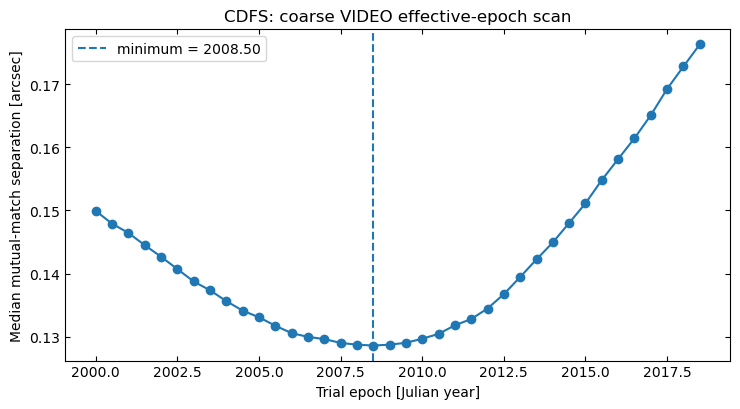

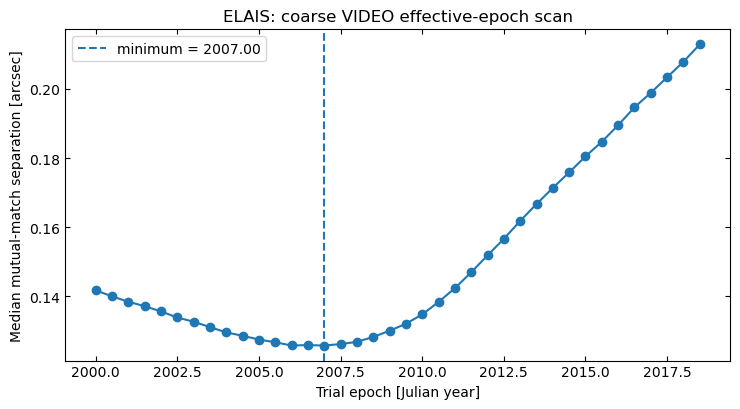

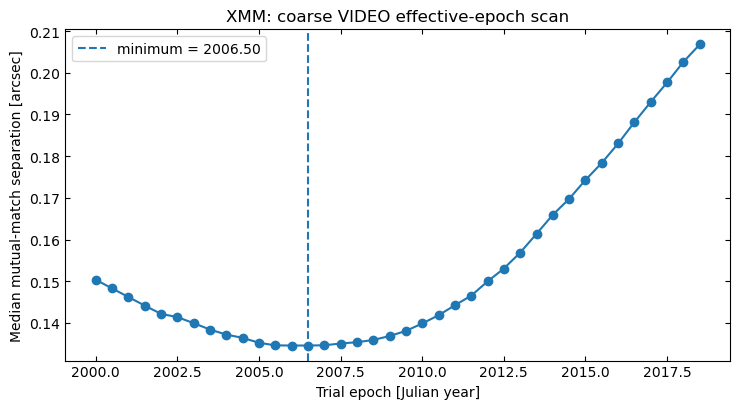

In [11]:
for field, scan in coarse_scans.items():

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "median_sep_arcsec"
        ],
        marker="o",
    )

    ax.axvline(
        coarse_best_epochs[
            field
        ],
        linestyle="--",
        label=(
            "minimum = "
            f"{coarse_best_epochs[field]:.2f}"
        ),
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Median mutual-match separation [arcsec]"
    )

    ax.set_title(
        f"{field}: coarse VIDEO effective-epoch scan"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

### Coarse-scan match-count plots

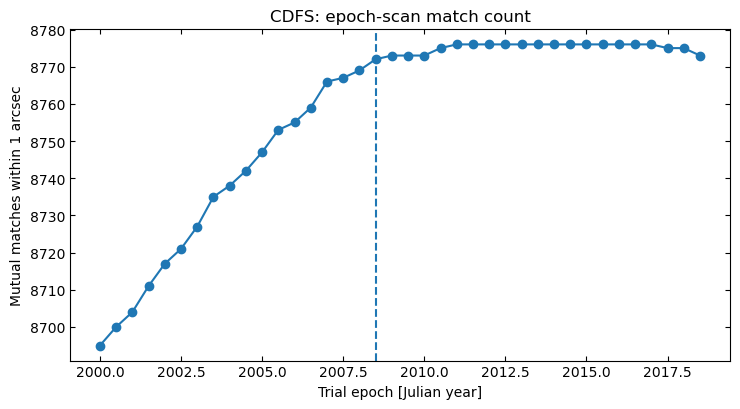

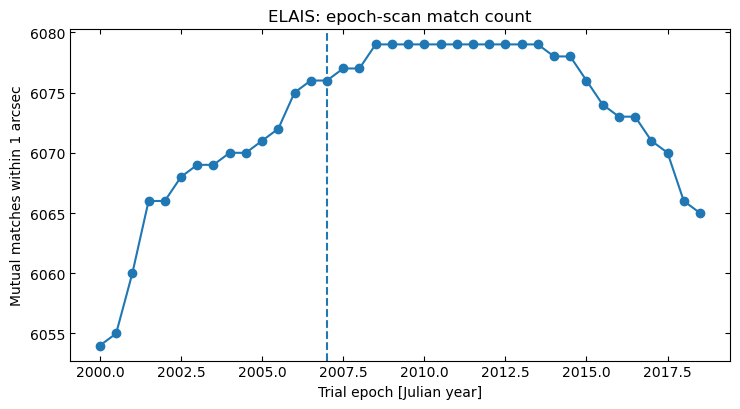

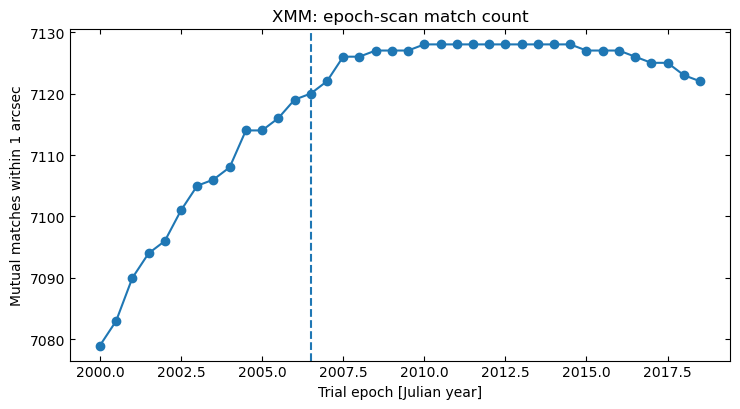

In [12]:
for field, scan in coarse_scans.items():

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "nmatch"
        ],
        marker="o",
    )

    ax.axvline(
        coarse_best_epochs[
            field
        ],
        linestyle="--",
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Mutual matches within 1 arcsec"
    )

    ax.set_title(
        f"{field}: epoch-scan match count"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    fig.tight_layout()
    plt.show()

### Fine effective-epoch scans — 0.1-year spacing

Each coarse minimum is refined over a \(\pm 1\)-year interval in 0.1-year steps. These data-derived effective epochs are used for the final Monster–VIDEO matches.

In [13]:
fine_scans = {}
VIDEO_EFFECTIVE_EPOCH = {}

for field in VIDEO_FILES:

    centre = coarse_best_epochs[
        field
    ]

    fine_grid = np.round(
        np.arange(
            centre
            - 1.0,
            centre
            + 1.0
            + 0.05,
            0.1,
        ),
        10,
    )

    scan = scan_effective_epoch(
        field,
        fine_grid,
    )

    fine_scans[
        field
    ] = scan

    VIDEO_EFFECTIVE_EPOCH[
        field
    ] = best_epoch(
        scan
    )

effective_epoch_table = pd.DataFrame(
    {
        "field":
            list(
                VIDEO_EFFECTIVE_EPOCH.keys()
            ),
        "effective_epoch_jyear":
            list(
                VIDEO_EFFECTIVE_EPOCH.values()
            ),
        "effective_epoch_mjd":
            [
                Time(
                    epoch,
                    format="jyear",
                ).mjd
                for epoch
                in VIDEO_EFFECTIVE_EPOCH.values()
            ],
    }
)

display(
    effective_epoch_table
)

,field,effective_epoch_jyear,effective_epoch_mjd
0,CDFS,2008.2,54539.550
1,ELAIS,2006.8,54028.200
2,XMM,2005.7,53626.425


### Fine-scan separation and match-count diagnostics

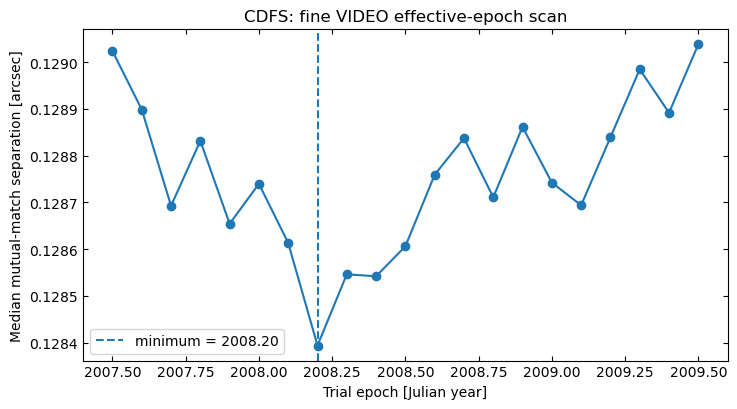

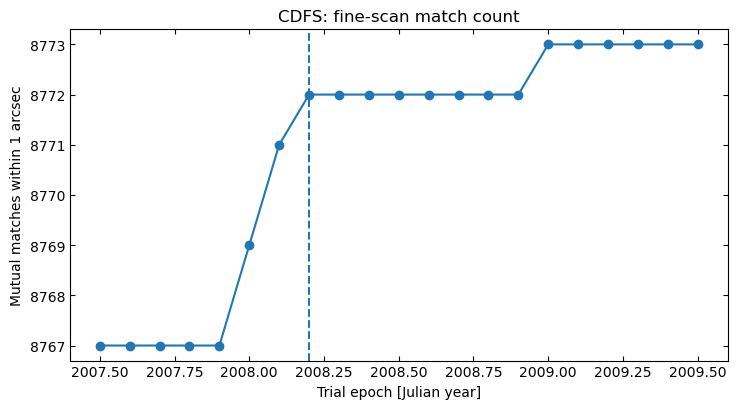

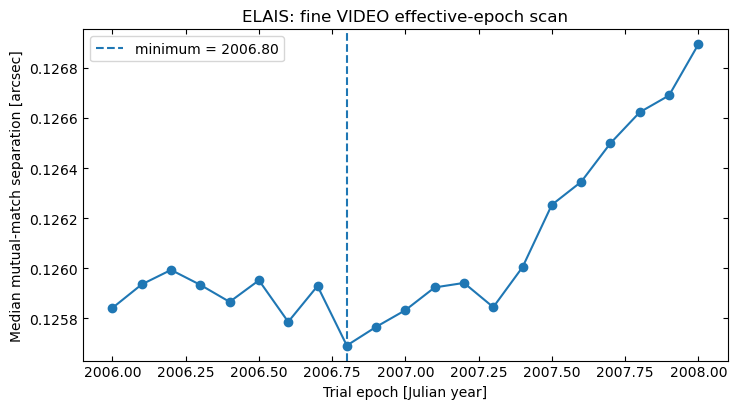

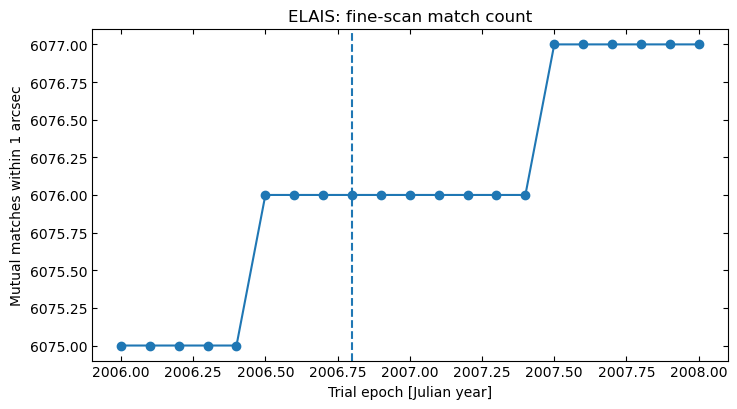

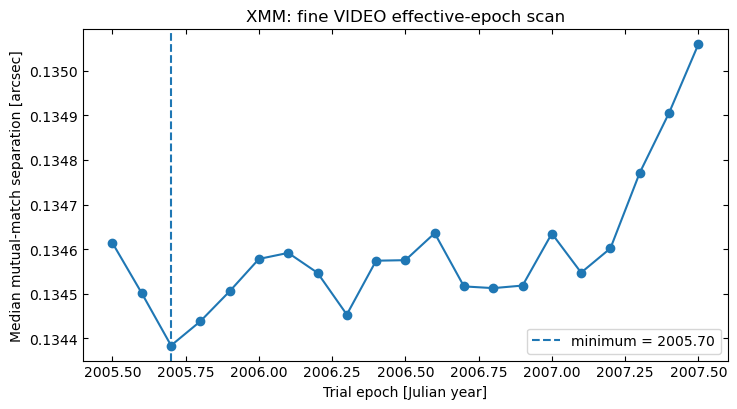

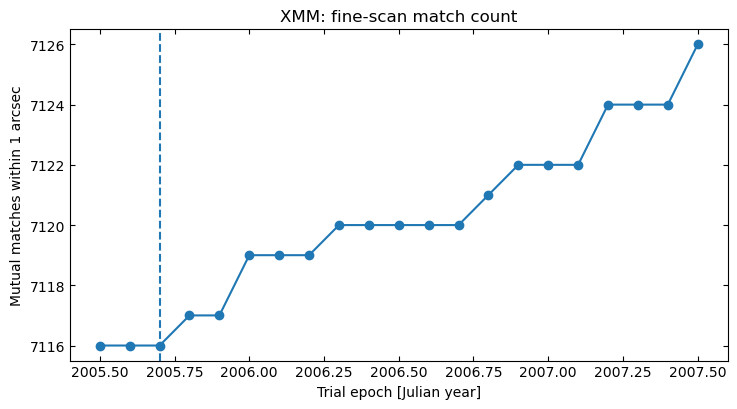

In [14]:
for field, scan in fine_scans.items():

    best = VIDEO_EFFECTIVE_EPOCH[
        field
    ]

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "median_sep_arcsec"
        ],
        marker="o",
    )

    ax.axvline(
        best,
        linestyle="--",
        label=(
            f"minimum = {best:.2f}"
        ),
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Median mutual-match separation [arcsec]"
    )

    ax.set_title(
        f"{field}: fine VIDEO effective-epoch scan"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "nmatch"
        ],
        marker="o",
    )

    ax.axvline(
        best,
        linestyle="--",
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Mutual matches within 1 arcsec"
    )

    ax.set_title(
        f"{field}: fine-scan match count"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    fig.tight_layout()
    plt.show()

### Construct the selected Y-band calibration sample

For each VIDEO field, Monster positions are propagated to the fitted effective epoch and matched to the VIDEO catalogue. The final calibration sample requires:

- mutual nearest-neighbour matching within 0.5 arcsec;
- secure Monster–VIDEO separation below 0.3 arcsec;
- Monster second-neighbour separation above 1 arcsec;
- finite positive Monster DES z/y and VIDEO Y fluxes;
- S/N >= 50 in Monster DES z, Monster DES y, and VIDEO Y;
- `KS_CLASS_STAR >= 0.90`;
- `Y_FLAGS == 0` and `KS_FLAGS == 0`;
- $14 < Y < 20$ AB mag.

The field-balanced spline is evaluated only over $-0.05 \le (z-y)_{\rm Monster} \le 0.175$. The fitted ratio is $F_{\mathrm{Monster,DES},y}/F_{\mathrm{VIDEO},Y}$.


In [15]:
def process_video_y_field(
    field,
):
    """Construct the selected Y calibration sample for one VIDEO field."""

    video = video_tables[
        field
    ]

    monster = monster_tables[
        field
    ]

    target_mjd = Time(
        VIDEO_EFFECTIVE_EPOCH[
            field
        ],
        format="jyear",
    ).mjd

    ra_video = float_array(
        video[
            "RA2000"
        ]
    )

    dec_video = float_array(
        video[
            "DEC2000"
        ]
    )

    video_coords = SkyCoord(
        ra=ra_video
        * u.deg,
        dec=dec_video
        * u.deg,
        frame="icrs",
    )

    (
        monster_coords,
        monster_use_index,
    ) = propagate_monster_pm_only(
        monster,
        target_mjd,
    )

    isolation = isolate_mask(
        monster_coords,
        MONSTER_ISOLATION_RADIUS,
    )

    isolated_coords = monster_coords[
        isolation
    ]

    isolated_monster_index = monster_use_index[
        isolation
    ]

    (
        gold,
        idx_video,
        separation,
    ) = mutual_nn_match(
        isolated_coords,
        video_coords,
        MATCH_RADIUS,
    )

    gold_monster_index = (
        isolated_monster_index[
            gold
        ]
    )

    gold_video_index = (
        idx_video[
            gold
        ]
    )

    gold_separation_arcsec = (
        separation[
            gold
        ]
        .to_value(
            u.arcsec
        )
    )

    if len(
        gold_monster_index
    ) == 0:
        raise RuntimeError(
            f"{field}: no Gold matches."
        )

    monster_id = integer_array(
        monster[
            "id"
        ][
            gold_monster_index
        ]
    )

    monster_z_flux = float_array(
        monster[
            "monster_DES_z_flux"
        ][
            gold_monster_index
        ]
    )

    monster_z_flux_err = float_array(
        monster[
            "monster_DES_z_fluxErr"
        ][
            gold_monster_index
        ]
    )

    monster_y_flux = float_array(
        monster[
            "monster_DES_y_flux"
        ][
            gold_monster_index
        ]
    )

    monster_y_flux_err = float_array(
        monster[
            "monster_DES_y_fluxErr"
        ][
            gold_monster_index
        ]
    )

    video_y_flux_adu = float_array(
        video[
            "Y_FLUX_APER_2"
        ][
            gold_video_index
        ]
    )

    video_y_flux_err_adu = float_array(
        video[
            "Y_FLUXERR_APER_2"
        ][
            gold_video_index
        ]
    )

    video_y_mag = float_array(
        video[
            "Y_MAG_APER_2"
        ][
            gold_video_index
        ]
    )

    video_y_mag_err = float_array(
        video[
            "Y_MAGERR_APER_2"
        ][
            gold_video_index
        ]
    )

    video_class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ][
            gold_video_index
        ]
    )

    video_ks_flags = integer_array(
        video[
            "KS_FLAGS"
        ][
            gold_video_index
        ],
        fill_value=999,
    )

    video_y_flags = integer_array(
        video[
            "Y_FLAGS"
        ][
            gold_video_index
        ],
        fill_value=999,
    )

    video_y_flux_njy = (
        video_y_flux_adu
        * VIDEO_ADU_TO_NJY
    )

    video_y_flux_err_njy = (
        video_y_flux_err_adu
        * VIDEO_ADU_TO_NJY
    )

    monster_z_snr = safe_snr(
        monster_z_flux,
        monster_z_flux_err,
    )

    monster_y_snr = safe_snr(
        monster_y_flux,
        monster_y_flux_err,
    )

    video_y_snr = safe_snr(
        video_y_flux_njy,
        video_y_flux_err_njy,
    )

    colour = np.full(
        len(
            monster_id
        ),
        np.nan,
        dtype=float,
    )

    valid_colour = (
        np.isfinite(
            monster_z_flux
        )
        & np.isfinite(
            monster_y_flux
        )
        & (
            monster_z_flux
            > 0.0
        )
        & (
            monster_y_flux
            > 0.0
        )
    )

    colour[
        valid_colour
    ] = (
        -2.5
        * np.log10(
            monster_z_flux[
                valid_colour
            ]
            / monster_y_flux[
                valid_colour
            ]
        )
    )

    ratio = np.full(
        len(
            monster_id
        ),
        np.nan,
        dtype=float,
    )

    valid_ratio = (
        np.isfinite(
            monster_y_flux
        )
        & np.isfinite(
            video_y_flux_njy
        )
        & (
            monster_y_flux
            > 0.0
        )
        & (
            video_y_flux_njy
            > 0.0
        )
    )

    ratio[
        valid_ratio
    ] = (
        monster_y_flux[
            valid_ratio
        ]
        / video_y_flux_njy[
            valid_ratio
        ]
    )

    finite_photometry = (
        np.isfinite(
            colour
        )
        & np.isfinite(
            ratio
        )
        & np.isfinite(
            video_y_mag
        )
        & np.isfinite(
            video_y_mag_err
        )
    )

    secure_separation = (
        gold_separation_arcsec
        < CALIBRATION_MATCH_RADIUS_ARCSEC
    )

    high_snr = (
        (
            video_y_snr
            >= MINIMUM_SNR
        )
        & (
            monster_z_snr
            >= MINIMUM_SNR
        )
        & (
            monster_y_snr
            >= MINIMUM_SNR
        )
    )

    stellar = (
        np.isfinite(
            video_class_star
        )
        & (
            video_class_star
            >= VIDEO_STAR_CLASS_MIN
        )
    )

    clean_flags = (
        (video_y_flags == 0)
        & (video_ks_flags == 0)
    )

    safe_magnitude = (
        video_y_mag
        > MINIMUM_Y_AB
    ) & (
        video_y_mag
        < MAXIMUM_Y_AB
    )

    selected_mask = (
        finite_photometry
        & secure_separation
        & high_snr
        & stellar
        & clean_flags
        & safe_magnitude
    )

    selected = Table()

    selected[
        "field"
    ] = np.full(
        np.count_nonzero(
            selected_mask
        ),
        field,
        dtype="U8",
    )

    selected[
        "monster_id"
    ] = monster_id[
        selected_mask
    ]

    selected[
        "monster_original_index"
    ] = gold_monster_index[
        selected_mask
    ].astype(
        np.int64
    )

    selected[
        "video_original_index"
    ] = gold_video_index[
        selected_mask
    ].astype(
        np.int64
    )

    selected[
        "separation_arcsec"
    ] = gold_separation_arcsec[
        selected_mask
    ]

    selected[
        "video_y_mag_ab"
    ] = video_y_mag[
        selected_mask
    ]

    selected[
        "video_y_magErr"
    ] = video_y_mag_err[
        selected_mask
    ]

    selected[
        "video_ks_class_star"
    ] = video_class_star[
        selected_mask
    ]

    selected[
        "video_ks_flags"
    ] = video_ks_flags[
        selected_mask
    ]

    selected[
        "video_y_flags"
    ] = video_y_flags[
        selected_mask
    ]

    selected[
        "video_y_flux_njy"
    ] = video_y_flux_njy[
        selected_mask
    ]

    selected[
        "video_y_fluxErr_njy"
    ] = video_y_flux_err_njy[
        selected_mask
    ]

    selected[
        "video_y_snr"
    ] = video_y_snr[
        selected_mask
    ]

    selected[
        "monster_z_flux_njy"
    ] = monster_z_flux[
        selected_mask
    ]

    selected[
        "monster_z_fluxErr_njy"
    ] = monster_z_flux_err[
        selected_mask
    ]

    selected[
        "monster_z_snr"
    ] = monster_z_snr[
        selected_mask
    ]

    selected[
        "monster_y_flux_njy"
    ] = monster_y_flux[
        selected_mask
    ]

    selected[
        "monster_y_fluxErr_njy"
    ] = monster_y_flux_err[
        selected_mask
    ]

    selected[
        "monster_y_snr"
    ] = monster_y_snr[
        selected_mask
    ]

    selected[
        "monster_zy_colour"
    ] = colour[
        selected_mask
    ]

    selected[
        "measured_ratio"
    ] = ratio[
        selected_mask
    ]

    summary = {
        "field":
            field,
        "monster_rows":
            len(
                monster
            ),
        "video_rows":
            len(
                video
            ),
        "pm_valid_monster":
            len(
                monster_coords
            ),
        "isolated_monster":
            int(
                np.count_nonzero(
                    isolation
                )
            ),
        "gold_matches_0p5":
            len(
                gold_monster_index
            ),
        "secure_matches_0p3":
            int(
                np.count_nonzero(
                    secure_separation
                )
            ),
        "selected_calibration_stars":
            int(
                np.count_nonzero(
                    selected_mask
                )
            ),
        "median_gold_separation_arcsec":
            float(
                np.median(
                    gold_separation_arcsec
                )
            ),
        "effective_epoch_jyear":
            VIDEO_EFFECTIVE_EPOCH[
                field
            ],
    }

    return (
        selected,
        summary,
    )


### Process CDFS, ELAIS-S1, and XMM-LSS

The three selected field samples are combined for diagnostics. Field labels are retained so that the spline nodes can be balanced across fields and leave-one-field-out validation can be performed later.


In [16]:
selected_field_tables = []

field_summary_records = []

for field in VIDEO_FILES:

    print(
        f"Processing {field} ..."
    )

    (
        selected,
        summary,
    ) = process_video_y_field(
        field
    )

    selected_field_tables.append(
        selected
    )

    field_summary_records.append(
        summary
    )

    print(
        f"  Gold within 0.5 arcsec : "
        f"{summary['gold_matches_0p5']:,}"
    )

    print(
        f"  Secure within 0.3 arcsec: "
        f"{summary['secure_matches_0p3']:,}"
    )

    print(
        f"  Selected calibration stars: "
        f"{summary['selected_calibration_stars']:,}"
    )


all_y_calibration_observations = vstack(
    selected_field_tables,
    join_type="exact",
    metadata_conflicts="silent",
)

field_processing_summary = pd.DataFrame(
    field_summary_records
)

display(
    field_processing_summary
)

print(
    "\nCombined selected observations:",
    f"{len(all_y_calibration_observations):,}",
)

Processing CDFS ...
  Gold within 0.5 arcsec : 13,052
  Secure within 0.3 arcsec: 12,675
  Selected calibration stars: 6,947
Processing ELAIS ...
  Gold within 0.5 arcsec : 9,359
  Secure within 0.3 arcsec: 9,110
  Selected calibration stars: 4,049
Processing XMM ...
  Gold within 0.5 arcsec : 11,326
  Secure within 0.3 arcsec: 10,725
  Selected calibration stars: 5,083


,field,monster_rows,video_rows,pm_valid_monster,isolated_monster,gold_matches_0p5,secure_matches_0p3,selected_calibration_stars,median_gold_separation_arcsec,effective_epoch_jyear
0,CDFS,55487,1138485,43039,42735,13052,12675,6947,0.129526,2008.2
1,ELAIS,35684,842337,27989,27821,9359,9110,4049,0.127276,2006.8
2,XMM,48013,1279857,38315,38253,11326,10725,5083,0.134432,2005.7



Combined selected observations: 16,079


### Check uniqueness and save the selected observations

A Monster source may appear in overlapping HTM coverage within the local field shard set only if the inputs themselves are inconsistent. The combined sample is checked and reduced to one row per Monster source before fitting.


In [17]:
all_ids = integer_array(
    all_y_calibration_observations[
        "monster_id"
    ]
)

all_snr = float_array(
    all_y_calibration_observations[
        "video_y_snr"
    ]
)

all_sep = float_array(
    all_y_calibration_observations[
        "separation_arcsec"
    ]
)

order = np.lexsort(
    (
        all_sep,
        -all_snr,
        all_ids,
    )
)

ordered = (
    all_y_calibration_observations[
        order
    ]
)

ordered_ids = integer_array(
    ordered[
        "monster_id"
    ]
)

_, first = np.unique(
    ordered_ids,
    return_index=True,
)

unique_y_calibration_sample = (
    ordered[
        np.sort(
            first
        )
    ]
)

print(
    "Selected observations:",
    f"{len(all_y_calibration_observations):,}",
)

print(
    "Unique Monster sources:",
    f"{len(unique_y_calibration_sample):,}",
)

print(
    "Repeated observations removed:",
    f"{len(all_y_calibration_observations) - len(unique_y_calibration_sample):,}",
)

ALL_OBSERVATIONS_PATH = (
    OUTPUT_DIR
    / "video_y_calibration_observations_all_fields.fits"
)

UNIQUE_SOURCES_PATH = (
    OUTPUT_DIR
    / "video_y_calibration_unique_sources.fits"
)

FIELD_SUMMARY_PATH = (
    OUTPUT_DIR
    / "video_y_field_processing_summary.csv"
)

all_y_calibration_observations.write(
    ALL_OBSERVATIONS_PATH,
    overwrite=True,
)

unique_y_calibration_sample.write(
    UNIQUE_SOURCES_PATH,
    overwrite=True,
)

field_processing_summary.to_csv(
    FIELD_SUMMARY_PATH,
    index=False,
)

print("\nSaved:")
print(
    f"  {ALL_OBSERVATIONS_PATH}"
)
print(
    f"  {UNIQUE_SOURCES_PATH}"
)
print(
    f"  {FIELD_SUMMARY_PATH}"
)

Selected observations: 16,079
Unique Monster sources: 16,079
Repeated observations removed: 0

Saved:
  data/outputs/Monster_VIDEO_Y/video_y_calibration_observations_all_fields.fits
  data/outputs/Monster_VIDEO_Y/video_y_calibration_unique_sources.fits
  data/outputs/Monster_VIDEO_Y/video_y_field_processing_summary.csv


### Inspect the colour–ratio relation by VIDEO field

The raw selected stars are plotted as Monster DES $(z-y)$ versus $F_{\mathrm{Monster,DES},y}/F_{\mathrm{VIDEO},Y}$, preserving the field labels. This provides the first direct check for field-dependent normalization or colour-shape differences.


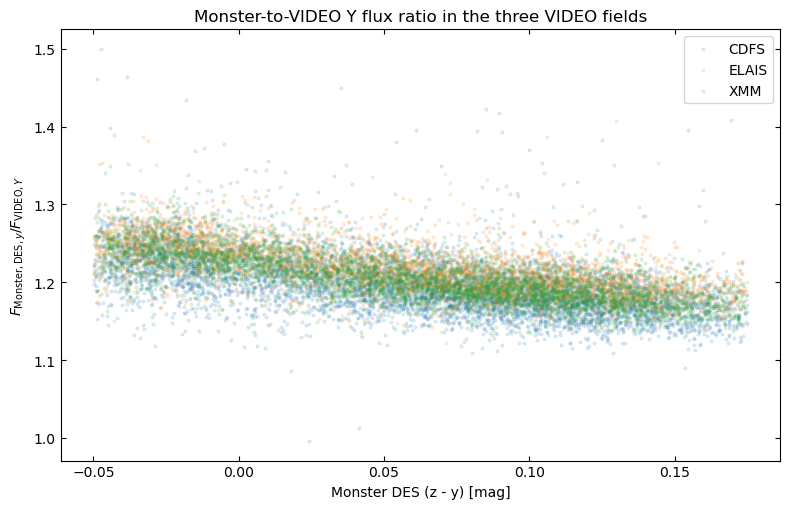

In [18]:
colour = float_array(
    unique_y_calibration_sample[
        "monster_zy_colour"
    ]
)

ratio = float_array(
    unique_y_calibration_sample[
        "measured_ratio"
    ]
)

field_name = np.asarray(
    unique_y_calibration_sample[
        "field"
    ]
).astype(
    str
)

plot_mask = (
    np.isfinite(
        colour
    )
    & np.isfinite(
        ratio
    )
    & (
        colour
        >= COLOUR_MIN
    )
    & (
        colour
        <= COLOUR_MAX
    )
    & (
        ratio
        > 0.5
    )
    & (
        ratio
        < 1.5
    )
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5.2,
    )
)

for field in VIDEO_FILES:

    selection = (
        plot_mask
        & (
            field_name
            == field
        )
    )

    ax.scatter(
        colour[
            selection
        ],
        ratio[
            selection
        ],
        s=4,
        alpha=0.12,
        label=field,
    )

ax.set_xlabel(
    "Monster DES (z - y) [mag]"
)

ax.set_ylabel(
    r"$F_{\mathrm{Monster,DES},y}/F_{\mathrm{VIDEO},Y}$"
)

ax.set_title(
    "Monster-to-VIDEO Y flux ratio in the three VIDEO fields"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

ax.legend()

fig.tight_layout()
plt.show()

### Construct field-balanced spline nodes

At each colour node, stars are selected within the corresponding colour bin. Ratios are clipped independently within each VIDEO field, a median is computed per field, and the node value is then the median of the available field medians. This prevents the deepest or largest field from dominating the transformation.


In [19]:
def node_edges(
    nodes,
):
    """Return bin edges centred on the supplied nodes."""

    nodes = np.asarray(
        nodes,
        dtype=float,
    )

    midpoints = 0.5 * (
        nodes[
            1:
        ]
        + nodes[
            :-1
        ]
    )

    first = (
        nodes[
            0
        ]
        - 0.5
        * (
            nodes[
                1
            ]
            - nodes[
                0
            ]
        )
    )

    last = (
        nodes[
            -1
        ]
        + 0.5
        * (
            nodes[
                -1
            ]
            - nodes[
                -2
            ]
        )
    )

    return np.concatenate(
        (
            [
                first,
            ],
            midpoints,
            [
                last,
            ],
        )
    )


def construct_field_balanced_nodes(
    table,
    nodes,
    allowed_fields=None,
):
    """Construct robust field-balanced ratio nodes."""

    if allowed_fields is None:
        allowed_fields = list(
            VIDEO_FILES
        )

    nodes = np.asarray(
        nodes,
        dtype=float,
    )

    edges = node_edges(
        nodes
    )

    colours = float_array(
        table[
            "monster_zy_colour"
        ]
    )

    ratios = float_array(
        table[
            "measured_ratio"
        ]
    )

    fields = np.asarray(
        table[
            "field"
        ]
    ).astype(
        str
    )

    records = []

    field_records = []

    for node_index, node in enumerate(
        nodes
    ):

        lower = edges[
            node_index
        ]

        upper = edges[
            node_index
            + 1
        ]

        # Include the upper boundary only in the final interval.
        if node_index == len(
            nodes
        ) - 1:

            in_interval = (
                np.isfinite(
                    colours
                )
                & np.isfinite(
                    ratios
                )
                & (
                    colours
                    >= lower
                )
                & (
                    colours
                    <= upper
                )
            )

        else:

            in_interval = (
                np.isfinite(
                    colours
                )
                & np.isfinite(
                    ratios
                )
                & (
                    colours
                    >= lower
                )
                & (
                    colours
                    < upper
                )
            )

        field_medians = []

        for field in allowed_fields:

            selection = (
                in_interval
                & (
                    fields
                    == field
                )
            )

            values = ratios[
                selection
            ]

            number_before = len(
                values
            )

            if (
                number_before
                < MINIMUM_STARS_PER_FIELD_BIN
            ):
                continue

            keep = iterative_nmad_clip(
                values,
                threshold=STAR_CLIP_THRESHOLD,
            )

            clipped = values[
                keep
            ]

            number_after = len(
                clipped
            )

            if (
                number_after
                < MINIMUM_STARS_PER_FIELD_BIN
            ):
                continue

            field_median = float(
                np.median(
                    clipped
                )
            )

            field_nmad = robust_nmad(
                clipped
            )

            field_medians.append(
                field_median
            )

            field_records.append(
                {
                    "node_colour":
                        float(
                            node
                        ),
                    "field":
                        field,
                    "colour_lower":
                        float(
                            lower
                        ),
                    "colour_upper":
                        float(
                            upper
                        ),
                    "n_before_clip":
                        number_before,
                    "n_after_clip":
                        number_after,
                    "field_median_ratio":
                        field_median,
                    "field_ratio_nmad":
                        field_nmad,
                }
            )

        field_medians = np.asarray(
            field_medians,
            dtype=float,
        )

        if len(
            field_medians
        ) < MINIMUM_FIELDS_PER_NODE:

            records.append(
                {
                    "node_colour":
                        float(
                            node
                        ),
                    "node_ratio":
                        np.nan,
                    "node_uncertainty":
                        np.nan,
                    "field_to_field_nmad":
                        np.nan,
                    "n_fields":
                        len(
                            field_medians
                        ),
                }
            )

            continue

        node_ratio = float(
            np.median(
                field_medians
            )
        )

        field_scatter = robust_nmad(
            field_medians
        )

        if (
            np.isfinite(
                field_scatter
            )
            and len(
                field_medians
            ) > 1
        ):
            node_uncertainty = (
                field_scatter
                / np.sqrt(
                    len(
                        field_medians
                    )
                )
            )
        else:
            node_uncertainty = np.nan

        records.append(
            {
                "node_colour":
                    float(
                        node
                    ),
                "node_ratio":
                    node_ratio,
                "node_uncertainty":
                    node_uncertainty,
                "field_to_field_nmad":
                    field_scatter,
                "n_fields":
                    len(
                        field_medians
                    ),
            }
        )

    return (
        pd.DataFrame(
            records
        ),
        pd.DataFrame(
            field_records
        ),
    )

### Diagnostic field-balanced nodes using all three fields

Before validation, confirm that every requested Y colour node has sufficient support from the VIDEO fields.


In [20]:
diagnostic_node_table, diagnostic_field_nodes = (
    construct_field_balanced_nodes(
        unique_y_calibration_sample,
        FINAL_NODES,
    )
)

display(
    diagnostic_node_table
)

if np.any(
    ~np.isfinite(
        diagnostic_node_table[
            "node_ratio"
        ].to_numpy(
            dtype=float
        )
    )
):
    raise RuntimeError(
        "At least one final node lacks sufficient VIDEO field support. "
        "Inspect diagnostic_node_table before changing the colour range."
    )

if np.any(
    diagnostic_node_table[
        "n_fields"
    ].to_numpy(
        dtype=int
    )
    < MINIMUM_FIELDS_PER_NODE
):
    raise RuntimeError(
        "At least one final node is supported by fewer than "
        f"{MINIMUM_FIELDS_PER_NODE} fields."
    )

,node_colour,node_ratio,node_uncertainty,field_to_field_nmad,n_fields
0,-5.000000e-02,1.238351,0.003464,0.006000,3
1,-2.500000e-02,1.239593,0.008409,0.014564,3
2,-6.938894e-18,1.230023,0.008201,0.014205,3
3,2.500000e-02,1.215197,0.006586,0.011408,3
4,5.000000e-02,1.204127,0.006673,0.011558,3
5,7.500000e-02,1.193553,0.005517,0.009556,3
6,1.000000e-01,1.187455,0.006737,0.011669,3
7,1.250000e-01,1.181145,0.005836,0.010108,3
8,1.500000e-01,1.174375,0.005916,0.010246,3
9,1.750000e-01,1.170307,0.009245,0.016012,3


### Field-to-field node consistency

The per-field medians are shown together with the field-balanced nodes. A coherent common shape with modest field offsets supports a single VIDEO-specific transformation.


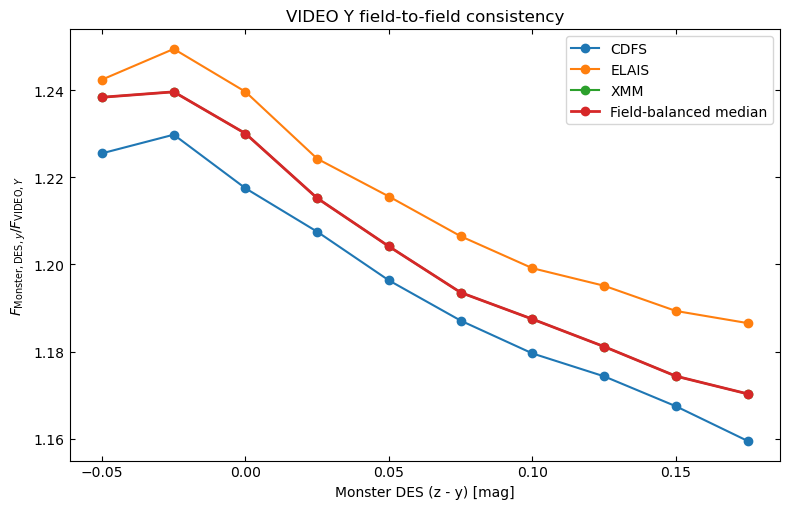

In [21]:
fig, ax = plt.subplots(
    figsize=(
        8,
        5.2,
    )
)

for field in VIDEO_FILES:

    sub = diagnostic_field_nodes[
        diagnostic_field_nodes[
            "field"
        ]
        == field
    ]

    ax.plot(
        sub[
            "node_colour"
        ],
        sub[
            "field_median_ratio"
        ],
        marker="o",
        label=field,
    )

ax.plot(
    diagnostic_node_table[
        "node_colour"
    ],
    diagnostic_node_table[
        "node_ratio"
    ],
    marker="o",
    linewidth=2,
    label="Field-balanced median",
)

ax.set_xlabel(
    "Monster DES (z - y) [mag]"
)

ax.set_ylabel(
    r"$F_{\mathrm{Monster,DES},y}/F_{\mathrm{VIDEO},Y}$"
)

ax.set_title(
    "VIDEO Y field-to-field consistency"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

ax.legend()

fig.tight_layout()
plt.show()

### Leave-one-field-out validation

Each VIDEO field is withheld in turn. The colour relation is fitted from the other two fields and used to predict the withheld field. This is the principal test of whether one VIDEO-wide Y transformation is supported by the data.


In [22]:
validation_tables = []

validation_summary_records = []

validation_node_tables = {}

for withheld_field in VIDEO_FILES:

    fitting_fields = [
        field
        for field in VIDEO_FILES
        if field
        != withheld_field
    ]

    fit_nodes, fit_field_nodes = (
        construct_field_balanced_nodes(
            unique_y_calibration_sample,
            FINAL_NODES,
            allowed_fields=fitting_fields,
        )
    )

    if np.any(
        ~np.isfinite(
            fit_nodes[
                "node_ratio"
            ].to_numpy(
                dtype=float
            )
        )
    ):
        raise RuntimeError(
            f"Leave-one-field-out fit for {withheld_field} "
            "has unsupported spline nodes."
        )

    spline = make_interp_spline(
        fit_nodes[
            "node_colour"
        ].to_numpy(
            dtype=float
        ),
        fit_nodes[
            "node_ratio"
        ].to_numpy(
            dtype=float
        ),
        k=3,
    )

    validation_node_tables[
        withheld_field
    ] = fit_nodes

    selection = (
        np.asarray(
            unique_y_calibration_sample[
                "field"
            ]
        ).astype(
            str
        )
        == withheld_field
    )

    validation = (
        unique_y_calibration_sample[
            selection
        ]
    )

    validation_colour = float_array(
        validation[
            "monster_zy_colour"
        ]
    )

    measured_ratio = float_array(
        validation[
            "measured_ratio"
        ]
    )

    monster_y_flux = float_array(
        validation[
            "monster_y_flux_njy"
        ]
    )

    observed_video_flux = float_array(
        validation[
            "video_y_flux_njy"
        ]
    )

    model_ratio = evaluate_spline(
        spline,
        validation_colour,
        FINAL_NODES[
            0
        ],
        FINAL_NODES[
            -1
        ],
    )

    valid = (
        np.isfinite(
            validation_colour
        )
        & np.isfinite(
            measured_ratio
        )
        & np.isfinite(
            model_ratio
        )
        & (
            model_ratio
            > 0.0
        )
        & np.isfinite(
            monster_y_flux
        )
        & (
            monster_y_flux
            > 0.0
        )
        & np.isfinite(
            observed_video_flux
        )
        & (
            observed_video_flux
            > 0.0
        )
    )

    ratio_residual = (
        measured_ratio[
            valid
        ]
        - model_ratio[
            valid
        ]
    )

    fractional_residual = (
        ratio_residual
        / model_ratio[
            valid
        ]
    )

    predicted_video_flux = (
        monster_y_flux[
            valid
        ]
        / model_ratio[
            valid
        ]
    )

    delta_mag = (
        -2.5
        * np.log10(
            predicted_video_flux
            / observed_video_flux[
                valid
            ]
        )
    )

    table = Table()

    table[
        "field"
    ] = np.full(
        np.count_nonzero(
            valid
        ),
        withheld_field,
        dtype="U8",
    )

    table[
        "monster_id"
    ] = integer_array(
        validation[
            "monster_id"
        ][
            valid
        ]
    )

    table[
        "monster_zy_colour"
    ] = validation_colour[
        valid
    ]

    table[
        "measured_ratio"
    ] = measured_ratio[
        valid
    ]

    table[
        "model_ratio"
    ] = model_ratio[
        valid
    ]

    table[
        "ratio_residual"
    ] = ratio_residual

    table[
        "fractional_residual"
    ] = fractional_residual

    table[
        "delta_mag"
    ] = delta_mag

    table[
        "video_y_mag_ab"
    ] = float_array(
        validation[
            "video_y_mag_ab"
        ][
            valid
        ]
    )

    validation_tables.append(
        table
    )

    validation_summary_records.append(
        {
            "withheld_field":
                withheld_field,
            "fitting_fields":
                "+".join(
                    fitting_fields
                ),
            "n_sources":
                len(
                    table
                ),
            "median_ratio_residual":
                float(
                    np.median(
                        ratio_residual
                    )
                ),
            "ratio_residual_nmad":
                robust_nmad(
                    ratio_residual
                ),
            "median_fractional_residual_percent":
                float(
                    100.0
                    * np.median(
                        fractional_residual
                    )
                ),
            "fractional_residual_nmad_percent":
                float(
                    100.0
                    * robust_nmad(
                        fractional_residual
                    )
                ),
            "median_delta_mag":
                float(
                    np.median(
                        delta_mag
                    )
                ),
            "delta_mag_nmad":
                robust_nmad(
                    delta_mag
                ),
        }
    )

validation_residuals = vstack(
    validation_tables,
    join_type="exact",
    metadata_conflicts="silent",
)

validation_summary = pd.DataFrame(
    validation_summary_records
)

display(
    validation_summary
)

,withheld_field,fitting_fields,n_sources,median_ratio_residual,ratio_residual_nmad,median_fractional_residual_percent,fractional_residual_nmad_percent,median_delta_mag,delta_mag_nmad
0,CDFS,ELAIS+XMM,6547,-0.013931,0.025024,-1.157425,2.074498,0.012640,0.022697
1,ELAIS,CDFS+XMM,3824,0.015726,0.019842,1.318460,1.657637,-0.014221,0.017765
2,XMM,CDFS+ELAIS,4839,-0.001397,0.018284,-0.115535,1.519935,0.001255,0.016503


### Leave-one-field-out residuals versus colour

The ratio residuals of each withheld field are inspected against Monster DES $(z-y)$ to identify any colour-dependent failure of the transformation.


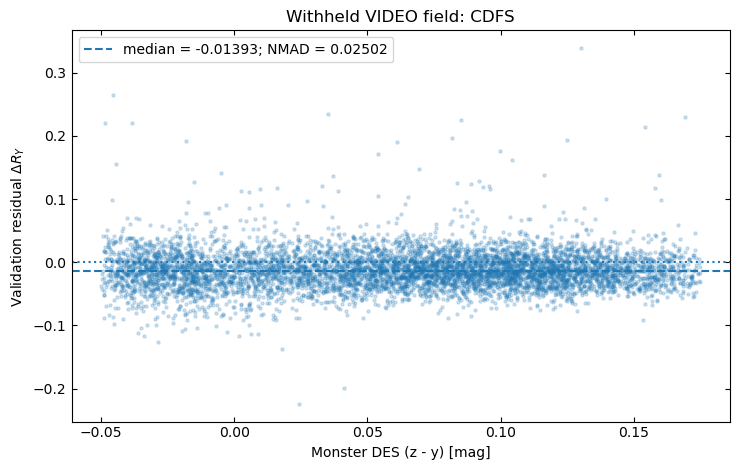

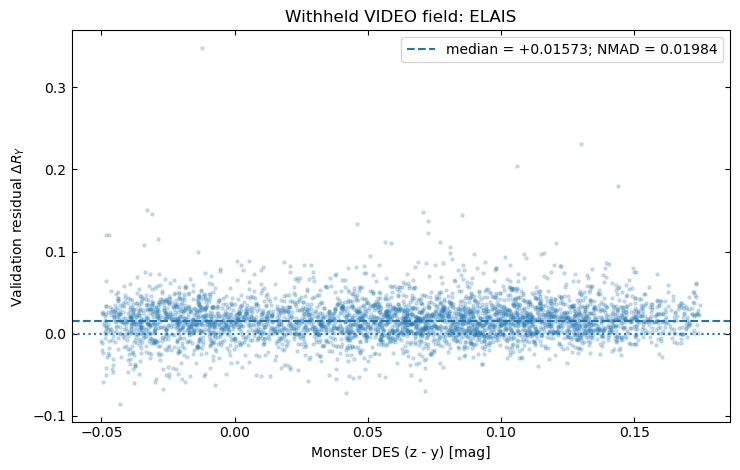

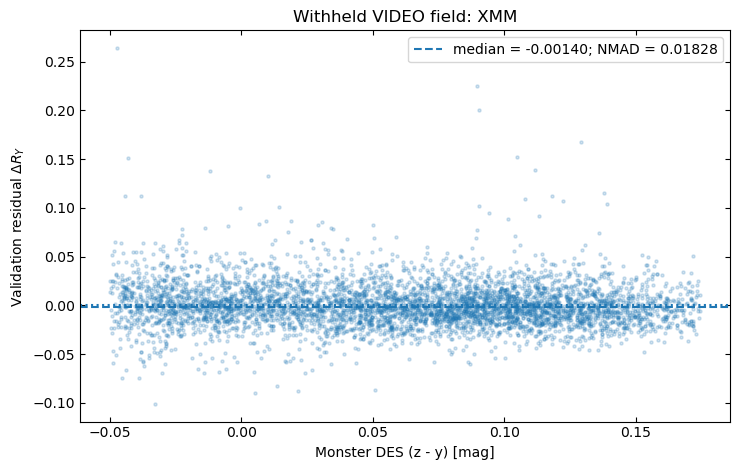

In [23]:
for withheld_field in VIDEO_FILES:

    selection = (
        np.asarray(
            validation_residuals[
                "field"
            ]
        ).astype(
            str
        )
        == withheld_field
    )

    colour_val = float_array(
        validation_residuals[
            "monster_zy_colour"
        ][
            selection
        ]
    )

    residual_val = float_array(
        validation_residuals[
            "ratio_residual"
        ][
            selection
        ]
    )

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.8,
        )
    )

    ax.scatter(
        colour_val,
        residual_val,
        s=5,
        alpha=0.20,
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.axhline(
        np.nanmedian(
            residual_val
        ),
        linestyle="--",
        label=(
            "median = "
            f"{np.nanmedian(residual_val):+.5f}; "
            "NMAD = "
            f"{robust_nmad(residual_val):.5f}"
        ),
    )

    ax.set_xlabel(
        "Monster DES (z - y) [mag]"
    )

    ax.set_ylabel(
        r"Validation residual $\Delta R_Y$"
    )

    ax.set_title(
        f"Withheld VIDEO field: {withheld_field}"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

### Leave-one-field-out residuals versus VIDEO Y magnitude

The predicted-minus-observed Y magnitude residuals are inspected against the measured VIDEO Y magnitude to reveal bright- or faint-end behaviour that is not obvious in colour space.


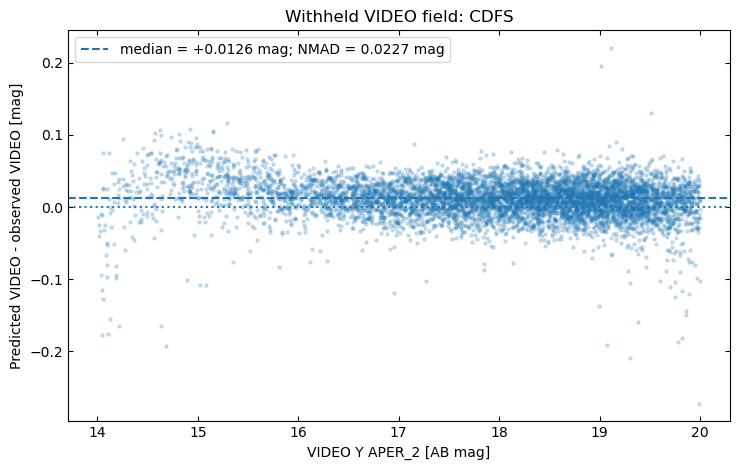

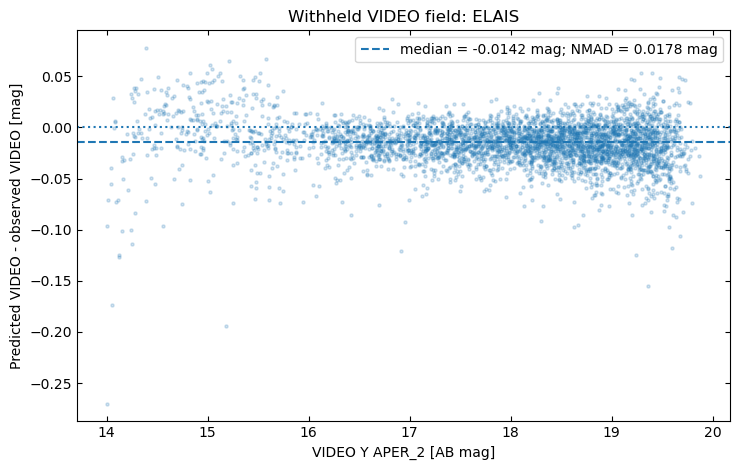

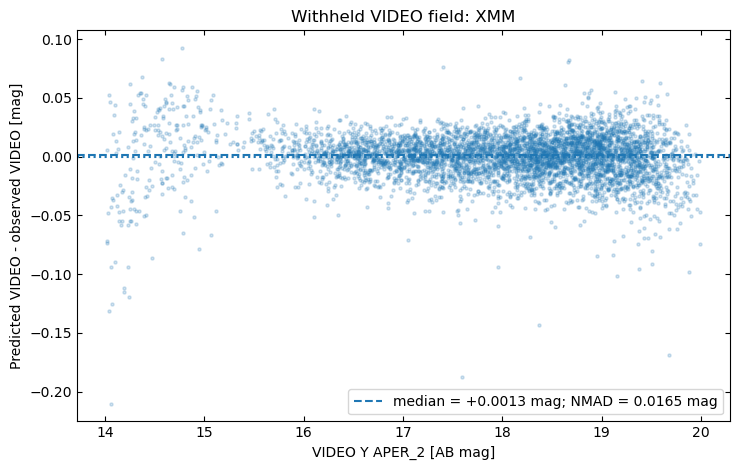

In [24]:
for withheld_field in VIDEO_FILES:

    selection = (
        np.asarray(
            validation_residuals[
                "field"
            ]
        ).astype(
            str
        )
        == withheld_field
    )

    magnitude = float_array(
        validation_residuals[
            "video_y_mag_ab"
        ][
            selection
        ]
    )

    delta_mag = float_array(
        validation_residuals[
            "delta_mag"
        ][
            selection
        ]
    )

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.8,
        )
    )

    ax.scatter(
        magnitude,
        delta_mag,
        s=5,
        alpha=0.20,
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.axhline(
        np.nanmedian(
            delta_mag
        ),
        linestyle="--",
        label=(
            "median = "
            f"{np.nanmedian(delta_mag):+.4f} mag; "
            "NMAD = "
            f"{robust_nmad(delta_mag):.4f} mag"
        ),
    )

    ax.set_xlabel(
        "VIDEO Y APER_2 [AB mag]"
    )

    ax.set_ylabel(
        "Predicted VIDEO - observed VIDEO [mag]"
    )

    ax.set_title(
        f"Withheld VIDEO field: {withheld_field}"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

### Refit the final field-balanced VIDEO Y spline using all three fields

The final relation is constructed only after all three leave-one-field-out tests complete successfully.


In [25]:
if "validation_summary" not in globals() or len(validation_summary) != len(VIDEO_FILES):
    raise RuntimeError(
        "Leave-one-field-out validation has not completed for all three fields. "
        "Stop here and fix the validation sample before fitting the final spline."
    )

final_node_table, final_field_node_table = (
    construct_field_balanced_nodes(
        unique_y_calibration_sample,
        FINAL_NODES,
        allowed_fields=list(
            VIDEO_FILES
        ),
    )
)

if np.any(
    ~np.isfinite(
        final_node_table[
            "node_ratio"
        ].to_numpy(
            dtype=float
        )
    )
):
    raise RuntimeError(
        "The final VIDEO Y spline has unsupported nodes."
    )

final_y_spline = make_interp_spline(
    final_node_table[
        "node_colour"
    ].to_numpy(
        dtype=float
    ),
    final_node_table[
        "node_ratio"
    ].to_numpy(
        dtype=float
    ),
    k=3,
)

final_colour_grid = np.linspace(
    FINAL_NODES[
        0
    ],
    FINAL_NODES[
        -1
    ],
    1000,
)

final_grid_ratio = final_y_spline(
    final_colour_grid
)

if np.any(
    ~np.isfinite(
        final_grid_ratio
    )
):
    raise RuntimeError(
        "Final spline contains non-finite values inside the calibrated interval."
    )

if np.any(
    final_grid_ratio
    <= 0.0
):
    raise RuntimeError(
        "Final spline contains non-positive flux ratios."
    )

display(
    final_node_table
)


,node_colour,node_ratio,node_uncertainty,field_to_field_nmad,n_fields
0,-5.000000e-02,1.238351,0.003464,0.006000,3
1,-2.500000e-02,1.239593,0.008409,0.014564,3
2,-6.938894e-18,1.230023,0.008201,0.014205,3
3,2.500000e-02,1.215197,0.006586,0.011408,3
4,5.000000e-02,1.204127,0.006673,0.011558,3
5,7.500000e-02,1.193553,0.005517,0.009556,3
6,1.000000e-01,1.187455,0.006737,0.011669,3
7,1.250000e-01,1.181145,0.005836,0.010108,3
8,1.500000e-01,1.174375,0.005916,0.010246,3
9,1.750000e-01,1.170307,0.009245,0.016012,3


### Final VIDEO Y colour transformation

The final plot combines the stellar density, field-specific medians, field-balanced nodes, and the cubic spline that will be written to the calibration YAML.


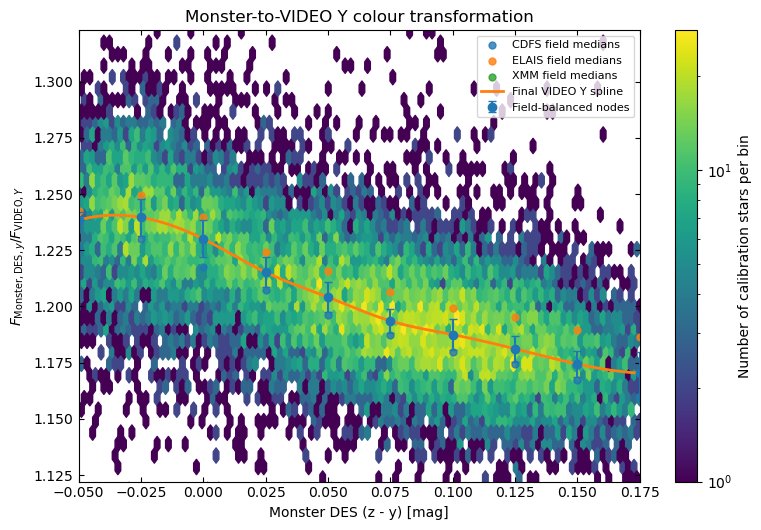

Saved: data/outputs/Monster_VIDEO_Y/video_y_final_colour_transformation.pdf


In [26]:
plot_mask = (
    np.isfinite(
        colour
    )
    & np.isfinite(
        ratio
    )
    & (
        colour
        >= FINAL_NODES[
            0
        ]
    )
    & (
        colour
        <= FINAL_NODES[
            -1
        ]
    )
)

ratio_plot_values = ratio[
    plot_mask
]

low_ratio, high_ratio = np.nanpercentile(
    ratio_plot_values,
    [
        0.5,
        99.5,
    ],
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5.4,
    )
)

hexbin = ax.hexbin(
    colour[
        plot_mask
    ],
    ratio[
        plot_mask
    ],
    gridsize=100,
    mincnt=1,
    bins="log",
)

for field in VIDEO_FILES:

    sub = final_field_node_table[
        final_field_node_table[
            "field"
        ]
        == field
    ]

    ax.scatter(
        sub[
            "node_colour"
        ],
        sub[
            "field_median_ratio"
        ],
        s=25,
        alpha=0.8,
        label=f"{field} field medians",
    )

ax.errorbar(
    final_node_table[
        "node_colour"
    ],
    final_node_table[
        "node_ratio"
    ],
    yerr=final_node_table[
        "node_uncertainty"
    ],
    fmt="o",
    capsize=3,
    label="Field-balanced nodes",
)

ax.plot(
    final_colour_grid,
    final_grid_ratio,
    linewidth=2,
    label="Final VIDEO Y spline",
)

ax.set_xlim(
    FINAL_NODES[
        0
    ],
    FINAL_NODES[
        -1
    ],
)

pad = 0.05 * (
    high_ratio
    - low_ratio
)

ax.set_ylim(
    low_ratio
    - pad,
    high_ratio
    + pad,
)

ax.set_xlabel(
    "Monster DES (z - y) [mag]"
)

ax.set_ylabel(
    r"$F_{\mathrm{Monster,DES},y}/F_{\mathrm{VIDEO},Y}$"
)

ax.set_title(
    "Monster-to-VIDEO Y colour transformation"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

ax.legend(
    fontsize=8
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of calibration stars per bin"
)

fig.tight_layout()

FINAL_TRANSFORMATION_PDF = (
    OUTPUT_DIR
    / "video_y_final_colour_transformation.pdf"
)

fig.savefig(
    FINAL_TRANSFORMATION_PDF,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {FINAL_TRANSFORMATION_PDF}"
)

### Direction test

The YAML stores the ratio $R_Y = F_{\mathrm{Monster,DES},y}/F_{\mathrm{VIDEO},Y}$. This cell explicitly verifies that the target VIDEO Y flux is recovered by **division**, not multiplication.


In [27]:
unique_colour = float_array(
    unique_y_calibration_sample[
        "monster_zy_colour"
    ]
)

unique_monster_y_flux = float_array(
    unique_y_calibration_sample[
        "monster_y_flux_njy"
    ]
)

unique_video_y_flux = float_array(
    unique_y_calibration_sample[
        "video_y_flux_njy"
    ]
)

model_ratio = evaluate_spline(
    final_y_spline,
    unique_colour,
    FINAL_NODES[
        0
    ],
    FINAL_NODES[
        -1
    ],
)

valid_direction = (
    np.isfinite(
        model_ratio
    )
    & (
        model_ratio
        > 0.0
    )
    & np.isfinite(
        unique_monster_y_flux
    )
    & (
        unique_monster_y_flux
        > 0.0
    )
    & np.isfinite(
        unique_video_y_flux
    )
    & (
        unique_video_y_flux
        > 0.0
    )
)

predicted_video_y_flux = (
    unique_monster_y_flux[
        valid_direction
    ]
    / model_ratio[
        valid_direction
    ]
)

fractional_flux_residual = (
    predicted_video_y_flux
    - unique_video_y_flux[
        valid_direction
    ]
) / unique_video_y_flux[
    valid_direction
]

delta_mag_direction = (
    -2.5
    * np.log10(
        predicted_video_y_flux
        / unique_video_y_flux[
            valid_direction
        ]
    )
)

print(
    f"Sources in direction test: "
    f"{np.count_nonzero(valid_direction):,}"
)

print(
    "Median fractional flux residual: "
    f"{100.0 * np.median(fractional_flux_residual):+.4f}%"
)

print(
    "Fractional flux residual NMAD: "
    f"{100.0 * robust_nmad(fractional_flux_residual):.4f}%"
)

print(
    "Median predicted-observed magnitude: "
    f"{np.median(delta_mag_direction):+.5f} mag"
)

print(
    "Magnitude NMAD: "
    f"{robust_nmad(delta_mag_direction):.5f} mag"
)

Sources in direction test: 15,210
Median fractional flux residual: +0.0197%
Fractional flux residual NMAD: 1.9125%
Median predicted-observed magnitude: -0.00021 mag
Magnitude NMAD: 0.02072 mag


### Optional comparison with the existing VIKING-derived Y transformation

If `Monster_to_VISTA_band_y.yaml` is present beside this notebook, the VIDEO-specific and VIKING-derived Y relations are plotted over their common colour interval.

This comparison is diagnostic only. The VIDEO fit is not shifted or otherwise adjusted to agree with VIKING.


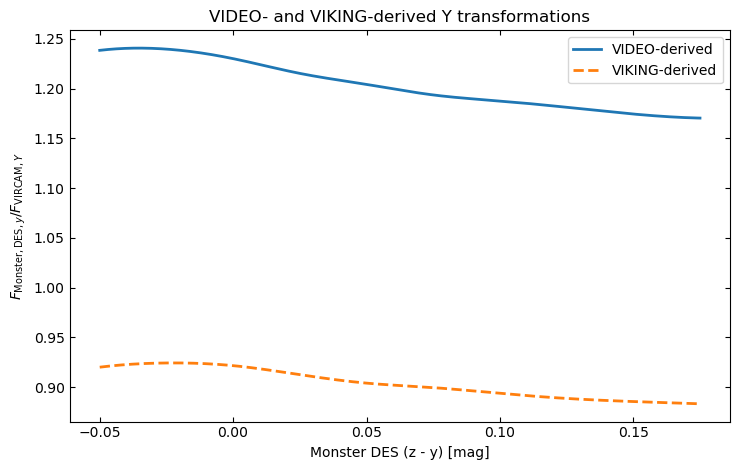

Median VIDEO-minus-VIKING ratio difference: +0.296923
Median implied VIDEO-target minus VIKING-target magnitude: +0.3092 mag


In [28]:
VIKING_YAML_PATH = Path(
    "Monster_to_VISTA_band_y.yaml"
)

if VIKING_YAML_PATH.exists():

    with VIKING_YAML_PATH.open(
        "r",
        encoding="utf-8",
    ) as stream:

        viking_yaml = yaml.safe_load(
            stream
        )

    viking_nodes = np.asarray(
        viking_yaml[
            "nodes"
        ],
        dtype=float,
    )

    viking_values = np.asarray(
        viking_yaml[
            "spline_values"
        ],
        dtype=float,
    )

    viking_spline = make_interp_spline(
        viking_nodes,
        viking_values,
        k=3,
    )

    common_min = max(
        FINAL_NODES[
            0
        ],
        viking_nodes[
            0
        ],
    )

    common_max = min(
        FINAL_NODES[
            -1
        ],
        viking_nodes[
            -1
        ],
    )

    common_colour = np.linspace(
        common_min,
        common_max,
        500,
    )

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.8,
        )
    )

    ax.plot(
        common_colour,
        final_y_spline(
            common_colour
        ),
        linewidth=2,
        label="VIDEO-derived",
    )

    ax.plot(
        common_colour,
        viking_spline(
            common_colour
        ),
        linewidth=2,
        linestyle="--",
        label="VIKING-derived",
    )

    ax.set_xlabel(
        "Monster DES (z - y) [mag]"
    )

    ax.set_ylabel(
        r"$F_{\mathrm{Monster,DES},y}/F_{\mathrm{VIRCAM},Y}$"
    )

    ax.set_title(
        "VIDEO- and VIKING-derived Y transformations"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

    ratio_difference = (
        final_y_spline(
            common_colour
        )
        - viking_spline(
            common_colour
        )
    )

    print(
        "Median VIDEO-minus-VIKING ratio difference: "
        f"{np.median(ratio_difference):+.6f}"
    )

    video_ratio_common = final_y_spline(
        common_colour
    )

    viking_ratio_common = viking_spline(
        common_colour
    )

    valid_comparison = (
        np.isfinite(
            video_ratio_common
        )
        & np.isfinite(
            viking_ratio_common
        )
        & (
            video_ratio_common > 0.0
        )
        & (
            viking_ratio_common > 0.0
        )
    )

    target_delta_mag = (
        -2.5
        * np.log10(
            (
                viking_ratio_common[
                    valid_comparison
                ]
                / video_ratio_common[
                    valid_comparison
                ]
            )
        )
    )

    print(
        "Median implied VIDEO-target minus VIKING-target magnitude: "
        f"{np.median(target_delta_mag):+.4f} mag"
    )

else:

    print(
        "Existing VIKING YAML not found; "
        "comparison skipped."
    )


### Write and verify `Monster_to_VIDEO_band_y.yaml`

The final YAML uses Monster DES z and y as the colour fields, Monster DES y as the source flux, and stores the field-balanced VIDEO Y ratio spline.


In [29]:
if "validation_summary" not in globals() or len(validation_summary) != len(VIDEO_FILES):
    raise RuntimeError(
        "Final YAML will not be written because three-field leave-one-field-out "
        "validation did not complete successfully."
    )

FINAL_YAML_OUTPUT = (
    OUTPUT_DIR
    / "Monster_to_VIDEO_band_y.yaml"
)

FINAL_YAML_REPOSITORY = Path(
    "Monster_to_VIDEO_band_y.yaml"
)

yaml_contents = {
    "flux_offset":
        0.0,
    "nodes":
        [
            float(
                value
            )
            for value
            in final_node_table[
                "node_colour"
            ]
        ],
    "source_color_field_1":
        "monster_DES_z_flux",
    "source_color_field_2":
        "monster_DES_y_flux",
    "source_field":
        "monster_DES_y_flux",
    "source_survey":
        "Monster",
    "spline_values":
        [
            float(
                value
            )
            for value
            in final_node_table[
                "node_ratio"
            ]
        ],
    "target_survey":
        "VISTA",
}


for path in [
    FINAL_YAML_OUTPUT,
    FINAL_YAML_REPOSITORY,
]:

    with path.open(
        "w",
        encoding="utf-8",
    ) as stream:

        yaml.safe_dump(
            yaml_contents,
            stream,
            sort_keys=False,
            default_flow_style=False,
        )


with FINAL_YAML_OUTPUT.open(
    "r",
    encoding="utf-8",
) as stream:

    reloaded_yaml = yaml.safe_load(
        stream
    )


if not np.allclose(
    np.asarray(
        reloaded_yaml[
            "nodes"
        ],
        dtype=float,
    ),
    FINAL_NODES,
):
    raise RuntimeError(
        "Reloaded VIDEO Y YAML nodes differ from final nodes."
    )


if not np.allclose(
    np.asarray(
        reloaded_yaml[
            "spline_values"
        ],
        dtype=float,
    ),
    final_node_table[
        "node_ratio"
    ].to_numpy(
        dtype=float
    ),
):
    raise RuntimeError(
        "Reloaded VIDEO Y YAML spline values differ from final fit."
    )


print(
    "Final VIDEO Y YAML written and verified:"
)

print(
    f"  {FINAL_YAML_OUTPUT}"
)

print(
    f"  {FINAL_YAML_REPOSITORY}"
)


Final VIDEO Y YAML written and verified:
  data/outputs/Monster_VIDEO_Y/Monster_to_VIDEO_band_y.yaml
  Monster_to_VIDEO_band_y.yaml


### Save final validation products

The fitted effective epochs, final field-balanced nodes, per-field node measurements, validation summary, and per-source leave-one-field-out residuals are written to the output directory.


In [30]:
EPOCH_TABLE_PATH = (
    OUTPUT_DIR
    / "video_y_effective_epochs.csv"
)

FINAL_NODE_PATH = (
    OUTPUT_DIR
    / "video_y_final_field_balanced_nodes.csv"
)

FIELD_NODE_PATH = (
    OUTPUT_DIR
    / "video_y_final_field_nodes.csv"
)

VALIDATION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "video_y_leave_one_field_out_summary.csv"
)

VALIDATION_RESIDUAL_PATH = (
    OUTPUT_DIR
    / "video_y_leave_one_field_out_residuals.fits"
)

effective_epoch_table.to_csv(
    EPOCH_TABLE_PATH,
    index=False,
)

final_node_table.to_csv(
    FINAL_NODE_PATH,
    index=False,
)

final_field_node_table.to_csv(
    FIELD_NODE_PATH,
    index=False,
)

validation_summary.to_csv(
    VALIDATION_SUMMARY_PATH,
    index=False,
)

validation_residuals.write(
    VALIDATION_RESIDUAL_PATH,
    overwrite=True,
)

print("Saved final validation products:")
for path in [
    EPOCH_TABLE_PATH,
    FINAL_NODE_PATH,
    FIELD_NODE_PATH,
    VALIDATION_SUMMARY_PATH,
    VALIDATION_RESIDUAL_PATH,
]:
    print(
        f"  {path}"
    )

Saved final validation products:
  data/outputs/Monster_VIDEO_Y/video_y_effective_epochs.csv
  data/outputs/Monster_VIDEO_Y/video_y_final_field_balanced_nodes.csv
  data/outputs/Monster_VIDEO_Y/video_y_final_field_nodes.csv
  data/outputs/Monster_VIDEO_Y/video_y_leave_one_field_out_summary.csv
  data/outputs/Monster_VIDEO_Y/video_y_leave_one_field_out_residuals.fits
